# EasyVisa Classification Project
## Visa Approval Prediction using Machine Learning

---

### Business Context

Business communities in the United States face high demand for human resources. The Immigration and Nationality Act (INA) permits foreign workers to work in the US on either a temporary or permanent basis. The Office of Foreign Labor Certification (OFLC) processes job certification applications for employers seeking to bring foreign workers into the United States.

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions - a 9% increase from the previous year. The increasing number of applicants calls for a Machine Learning based solution to help shortlist candidates having higher chances of VISA approval.

### Objective

As a data scientist at EasyVisa, we need to:
1. **Facilitate the process of visa approvals** through predictive modeling
2. **Recommend suitable profiles** for applicants for whom the visa should be certified or denied
3. **Identify key drivers** that significantly influence the case status

### Data Dictionary

| Feature | Description |
|---------|-------------|
| case_id | ID of each visa application |
| continent | Information of continent the employee belongs to |
| education_of_employee | Education level of the employee |
| has_job_experience | Does the employee have job experience? (Y/N) |
| requires_job_training | Does the employee require job training? (Y/N) |
| no_of_employees | Number of employees in the employer's company |
| yr_of_estab | Year in which the employer's company was established |
| region_of_employment | Foreign worker's intended region of employment in the US |
| prevailing_wage | Average wage paid to similar workers in the occupation/area |
| unit_of_wage | Unit of prevailing wage (Hourly, Weekly, Monthly, Yearly) |
| full_time_position | Is the position full-time? (Y/N) |
| case_status | Target - Visa certified or denied |

---
## 1. Import Libraries and Load Data

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Sklearn imports
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Classification models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report, roc_auc_score, 
                             roc_curve, precision_recall_curve, auc)

# Imbalanced-learn for resampling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('/Users/lakshmanraghu/Downloads/EasyVisa.csv')

# Create a copy for analysis
data = df.copy()

print(f"Dataset Shape: {data.shape}")
print(f"Total Records: {data.shape[0]:,}")
print(f"Total Features: {data.shape[1]}")

Dataset Shape: (25480, 12)
Total Records: 25,480
Total Features: 12


In [3]:
# First look at the data
data.head(10)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified
5,EZYV06,Asia,Master's,Y,N,2339,2012,South,78252.140,Year,Y,Certified
6,EZYV07,Asia,Bachelor's,N,N,4985,1994,South,53635.390,Year,Y,Certified
7,EZYV08,North America,Bachelor's,Y,N,3035,1924,West,418.230,Hour,Y,Denied
8,EZYV09,Asia,Bachelor's,N,N,4810,2012,Midwest,74362.190,Year,Y,Certified
9,EZYV10,Europe,Doctorate,Y,N,2251,1995,South,67514.760,Year,Y,Certified


In [4]:
# Data types and info
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  str    
 1   continent              25480 non-null  str    
 2   education_of_employee  25480 non-null  str    
 3   has_job_experience     25480 non-null  str    
 4   requires_job_training  25480 non-null  str    
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  str    
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  str    
 10  full_time_position     25480 non-null  str    
 11  case_status            25480 non-null  str    
dtypes: float64(1), int64(2), str(9)
memory usage: 2.3 MB


In [5]:
# Statistical summary for numerical columns
data.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000,25480.000,25480.000
mean,5667.043,1979.410,74455.815
std,22877.929,42.367,52815.942
min,-26.000,1800.000,2.137
25%,1022.000,1976.000,34015.480
50%,2109.000,1997.000,70308.210
75%,3504.000,2005.000,107735.513
max,602069.000,2016.000,319210.270


In [6]:
# Statistical summary for categorical columns
data.describe(include='object')

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,region_of_employment,unit_of_wage,full_time_position,case_status
count,25480,25480,25480,25480,25480,25480,25480,25480,25480
unique,25480,6,4,2,2,5,4,2,2
top,EZYV01,Asia,Bachelor's,Y,N,Northeast,Year,Y,Certified
freq,1,16861,10234,14802,22525,7195,22962,22773,17018


---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Data Overview and Quality Check

In [7]:
# Check for missing values
missing_values = data.isnull().sum()
missing_percentage = (data.isnull().sum() / len(data)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

print("Missing Values Analysis:")
print("=" * 50)
print(missing_df[missing_df['Missing Values'] > 0] if missing_df['Missing Values'].sum() > 0 else "No missing values found!")

Missing Values Analysis:
No missing values found!


In [8]:
# Check for duplicate records
duplicates = data.duplicated().sum()
print(f"Number of duplicate records: {duplicates}")

# Check for duplicate case_ids
duplicate_ids = data['case_id'].duplicated().sum()
print(f"Duplicate case_ids: {duplicate_ids}")

Number of duplicate records: 0
Duplicate case_ids: 0


In [9]:
# Unique values in each column
print("Unique Values in Each Column:")
print("=" * 50)
for col in data.columns:
    print(f"{col}: {data[col].nunique()} unique values")

Unique Values in Each Column:
case_id: 25480 unique values
continent: 6 unique values
education_of_employee: 4 unique values
has_job_experience: 2 unique values
requires_job_training: 2 unique values
no_of_employees: 7105 unique values
yr_of_estab: 199 unique values
region_of_employment: 5 unique values
prevailing_wage: 25454 unique values
unit_of_wage: 4 unique values
full_time_position: 2 unique values
case_status: 2 unique values


In [10]:
# Separate numerical and categorical columns
numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

# Remove case_id from analysis as it's just an identifier
if 'case_id' in categorical_cols:
    categorical_cols.remove('case_id')

print(f"Numerical Columns ({len(numerical_cols)}): {numerical_cols}")
print(f"\nCategorical Columns ({len(categorical_cols)}): {categorical_cols}")

Numerical Columns (3): ['no_of_employees', 'yr_of_estab', 'prevailing_wage']

Categorical Columns (8): ['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


### 2.2 Target Variable Analysis

Target Variable Distribution:
Certified: 17,018 (66.79%)
Denied: 8,462 (33.21%)


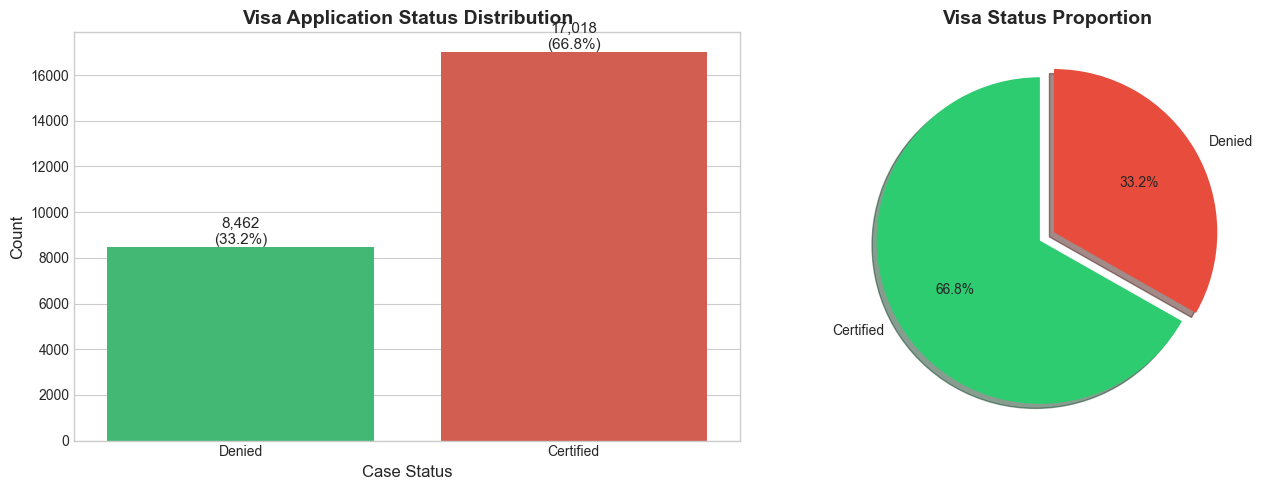


** Observation: The dataset is imbalanced with more Certified cases than Denied cases. **


In [11]:
# Target variable distribution
target_dist = data['case_status'].value_counts()
target_pct = data['case_status'].value_counts(normalize=True) * 100

print("Target Variable Distribution:")
print("=" * 50)
for status, count in target_dist.items():
    print(f"{status}: {count:,} ({target_pct[status]:.2f}%)")

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
colors = ['#2ecc71', '#e74c3c']
ax1 = sns.countplot(data=data, x='case_status', palette=colors, ax=axes[0])
axes[0].set_title('Visa Application Status Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Case Status', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

# Add value labels on bars
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height()):,}\n({p.get_height()/len(data)*100:.1f}%)', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11)

# Pie chart
axes[1].pie(target_dist, labels=target_dist.index, autopct='%1.1f%%', colors=colors,
            explode=[0.05, 0.05], shadow=True, startangle=90)
axes[1].set_title('Visa Status Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n** Observation: The dataset is imbalanced with more Certified cases than Denied cases. **")

### 2.3 Univariate Analysis - Categorical Variables

In [12]:
# Categorical columns for analysis (excluding case_id and target)
cat_cols_analysis = [col for col in categorical_cols if col != 'case_status']

# Display value counts for each categorical column
for col in cat_cols_analysis:
    print(f"\n{col.upper()}:")
    print("-" * 40)
    print(data[col].value_counts())


CONTINENT:
----------------------------------------
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

EDUCATION_OF_EMPLOYEE:
----------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64

HAS_JOB_EXPERIENCE:
----------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64

REQUIRES_JOB_TRAINING:
----------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64

REGION_OF_EMPLOYMENT:
----------------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: count, dtype: int64

UNIT_OF_WAGE:
----------------------------------------
unit_of_wage
Year     22962
Hour      2157
Week       2

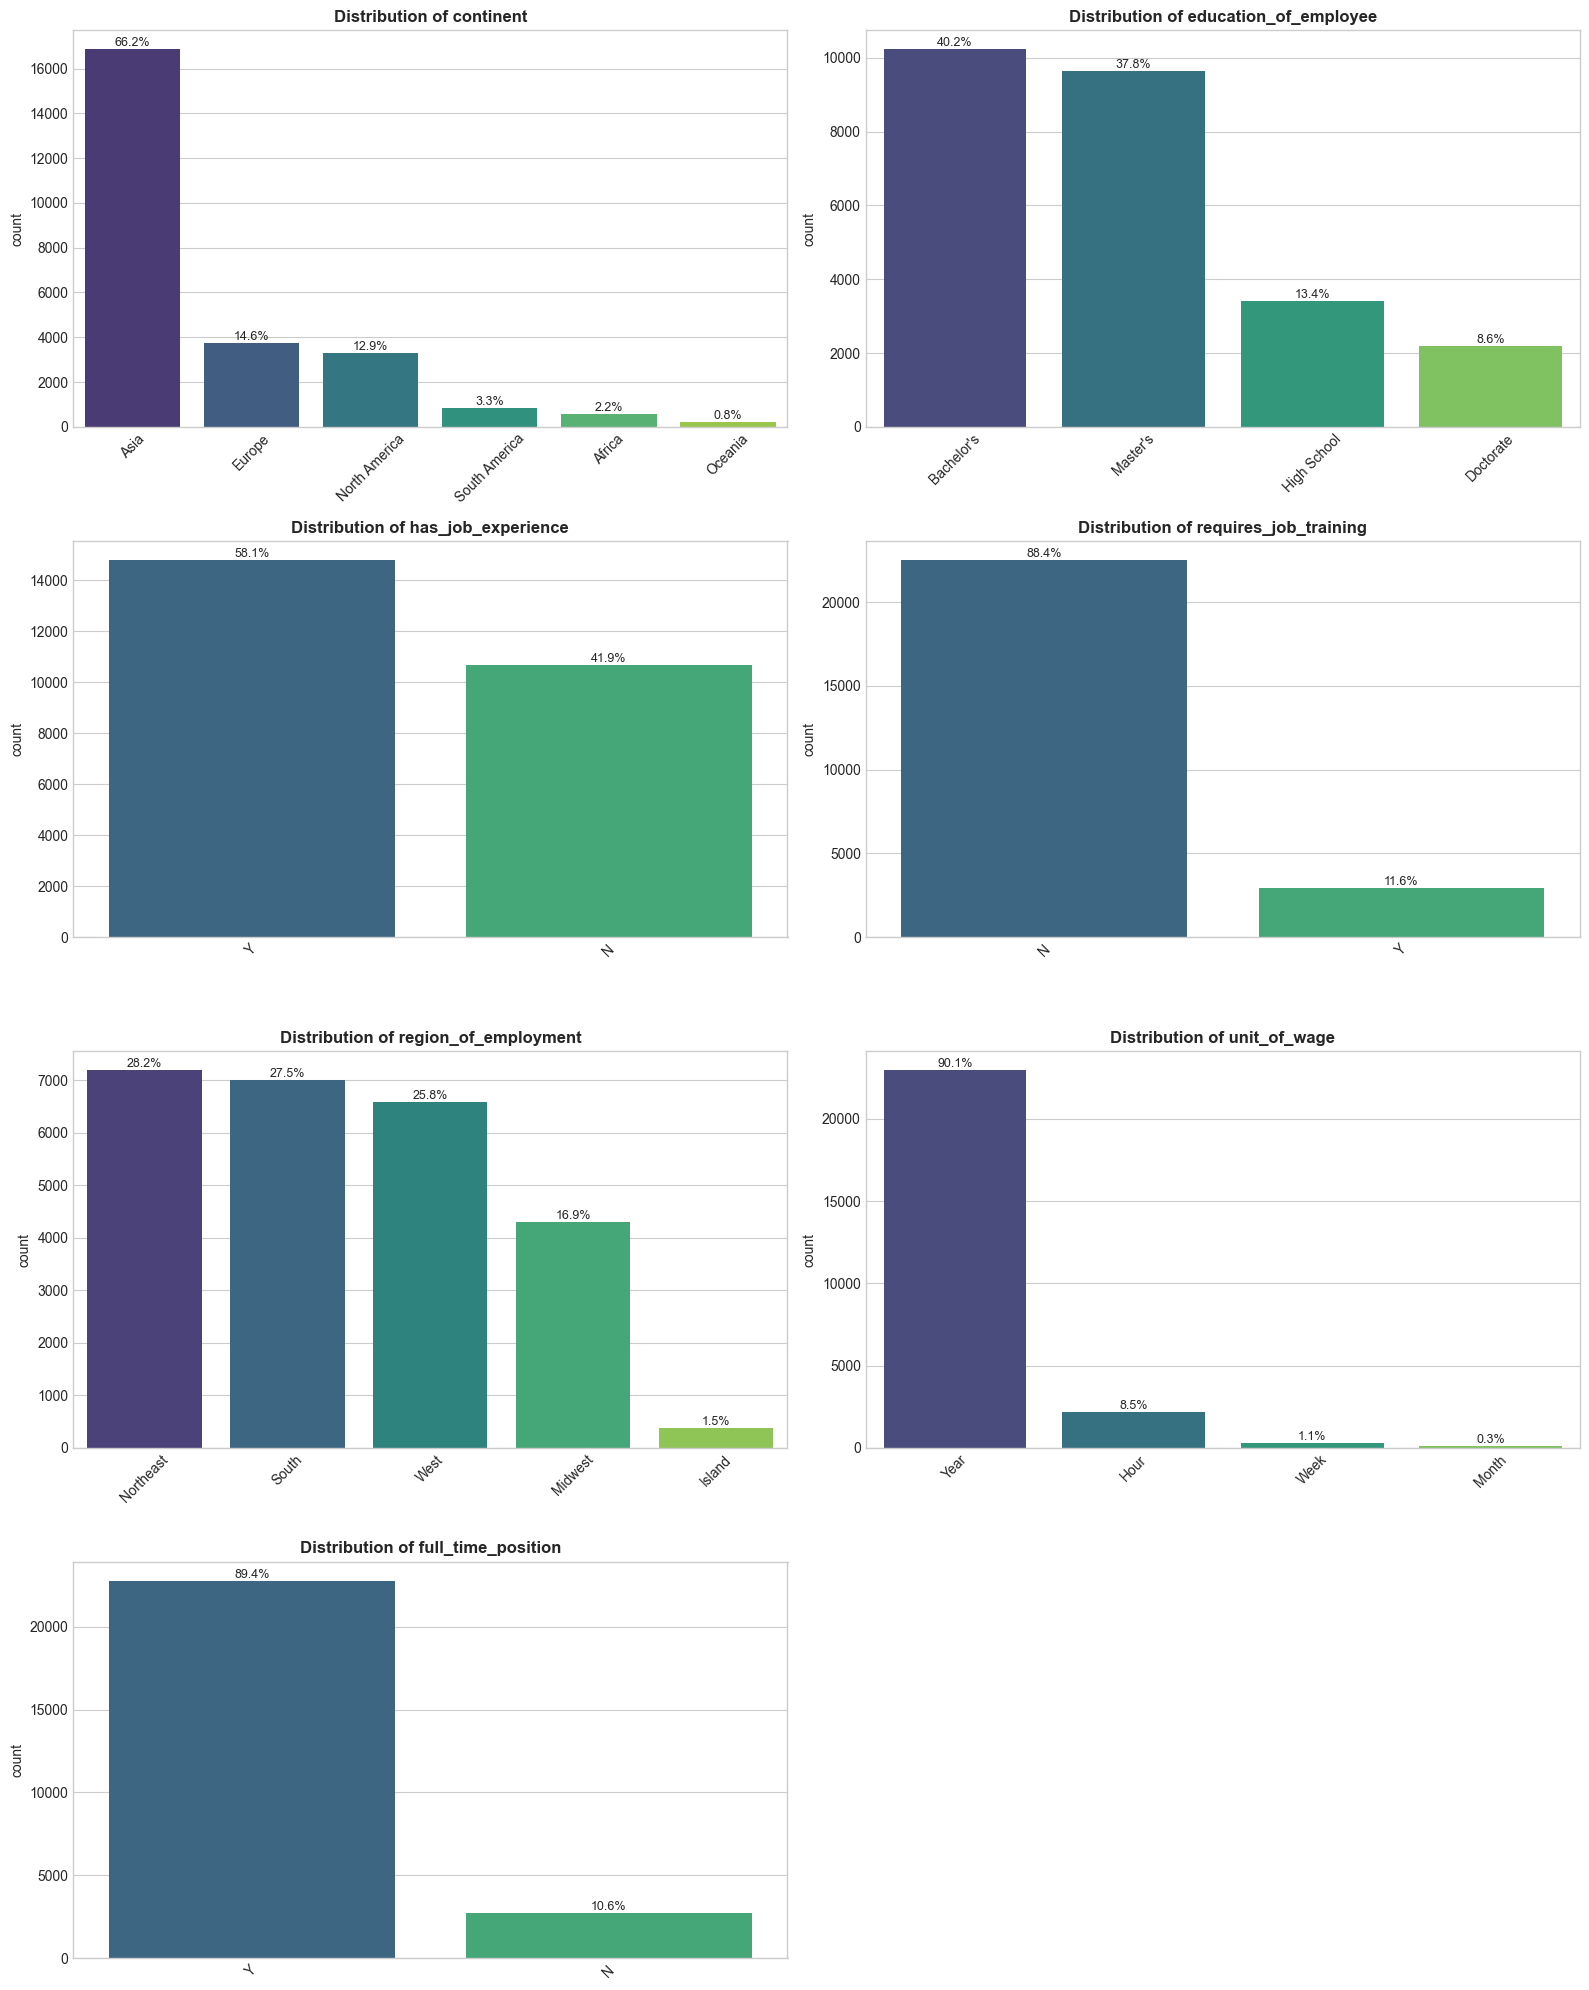

In [13]:
# Visualize categorical variables
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for idx, col in enumerate(cat_cols_analysis):
    order = data[col].value_counts().index
    sns.countplot(data=data, x=col, order=order, palette='viridis', ax=axes[idx])
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].tick_params(axis='x', rotation=45)
    
    # Add percentage labels
    total = len(data)
    for p in axes[idx].patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        axes[idx].annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                          ha='center', va='bottom', fontsize=9)

# Remove empty subplot if any
if len(cat_cols_analysis) < len(axes):
    for idx in range(len(cat_cols_analysis), len(axes)):
        fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

**Key Observations - Categorical Variables:**

1. **Continent**: Majority of applicants are from Asia, followed by Europe and North America
2. **Education**: Bachelor's and Master's degrees dominate, followed by High School and Doctorate
3. **Job Experience**: More applicants have job experience (Y) than those without (N)
4. **Job Training Required**: Most applicants do NOT require job training
5. **Full-time Position**: Vast majority are full-time positions
6. **Region of Employment**: Distribution across all US regions with slight variations

### 2.4 Univariate Analysis - Numerical Variables

In [14]:
# Numerical columns for analysis
print("Numerical Variables Summary Statistics:")
print("=" * 60)
display(data[numerical_cols].describe().T)

Numerical Variables Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.000,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
prevailing_wage,25480.000,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270


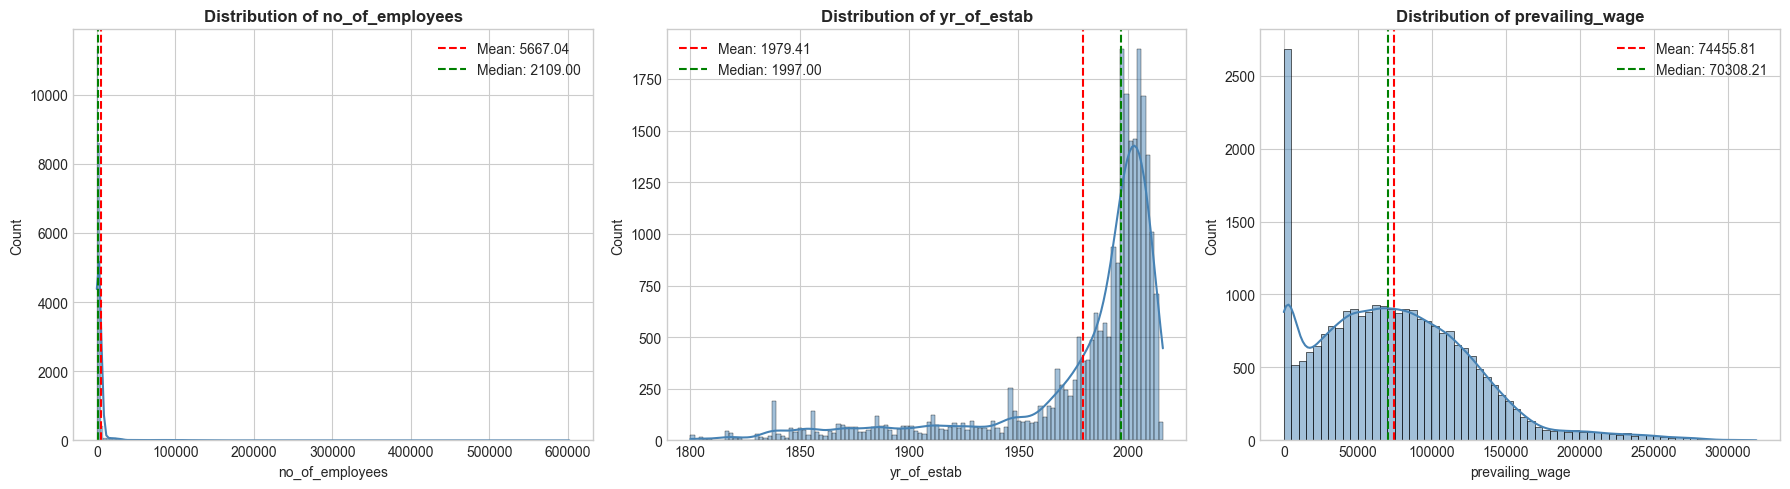

In [15]:
# Distribution plots for numerical variables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(numerical_cols):
    # Histogram with KDE
    sns.histplot(data=data, x=col, kde=True, ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].axvline(data[col].mean(), color='red', linestyle='--', label=f'Mean: {data[col].mean():.2f}')
    axes[idx].axvline(data[col].median(), color='green', linestyle='--', label=f'Median: {data[col].median():.2f}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

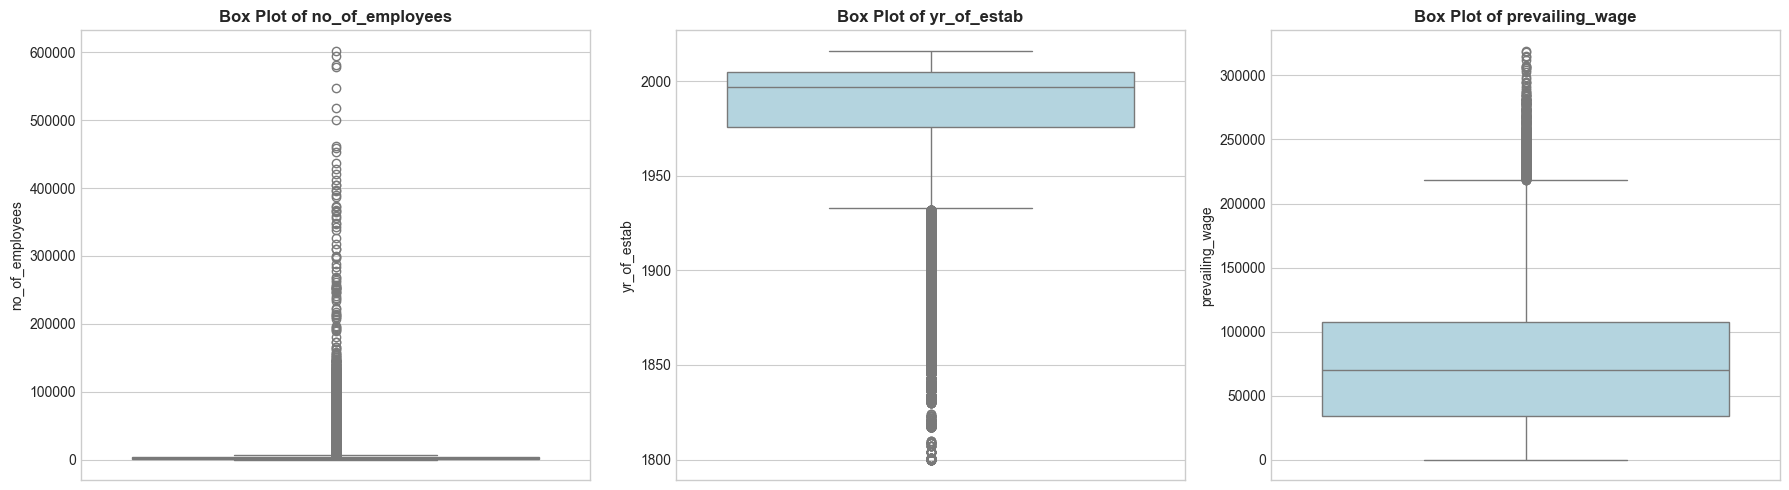


** Observation: Outliers are visible in 'no_of_employees' and 'prevailing_wage' columns **


In [16]:
# Box plots for numerical variables to identify outliers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(numerical_cols):
    sns.boxplot(data=data, y=col, ax=axes[idx], color='lightblue')
    axes[idx].set_title(f'Box Plot of {col}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n** Observation: Outliers are visible in 'no_of_employees' and 'prevailing_wage' columns **")

In [17]:
# Detailed outlier analysis using IQR method
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("Outlier Analysis (IQR Method):")
print("=" * 70)
for col in numerical_cols:
    n_outliers, lb, ub = detect_outliers_iqr(data, col)
    pct = (n_outliers / len(data)) * 100
    print(f"{col}:")
    print(f"  - Outliers: {n_outliers:,} ({pct:.2f}%)")
    print(f"  - Valid Range: [{lb:.2f}, {ub:.2f}]")
    print()

Outlier Analysis (IQR Method):
no_of_employees:
  - Outliers: 1,556 (6.11%)
  - Valid Range: [-2701.00, 7227.00]

yr_of_estab:
  - Outliers: 3,260 (12.79%)
  - Valid Range: [1932.50, 2048.50]

prevailing_wage:
  - Outliers: 427 (1.68%)
  - Valid Range: [-76564.57, 218315.56]



**Key Observations - Numerical Variables:**

1. **no_of_employees**: Right-skewed distribution with outliers representing large corporations. Range from small businesses to large enterprises.
2. **yr_of_estab**: Companies established from as early as 1800s to recent years. Majority are relatively newer companies.
3. **prevailing_wage**: Wide range of wages indicating diverse job categories. Presence of outliers on both ends.

### 2.5 Bivariate Analysis - Categorical vs Target

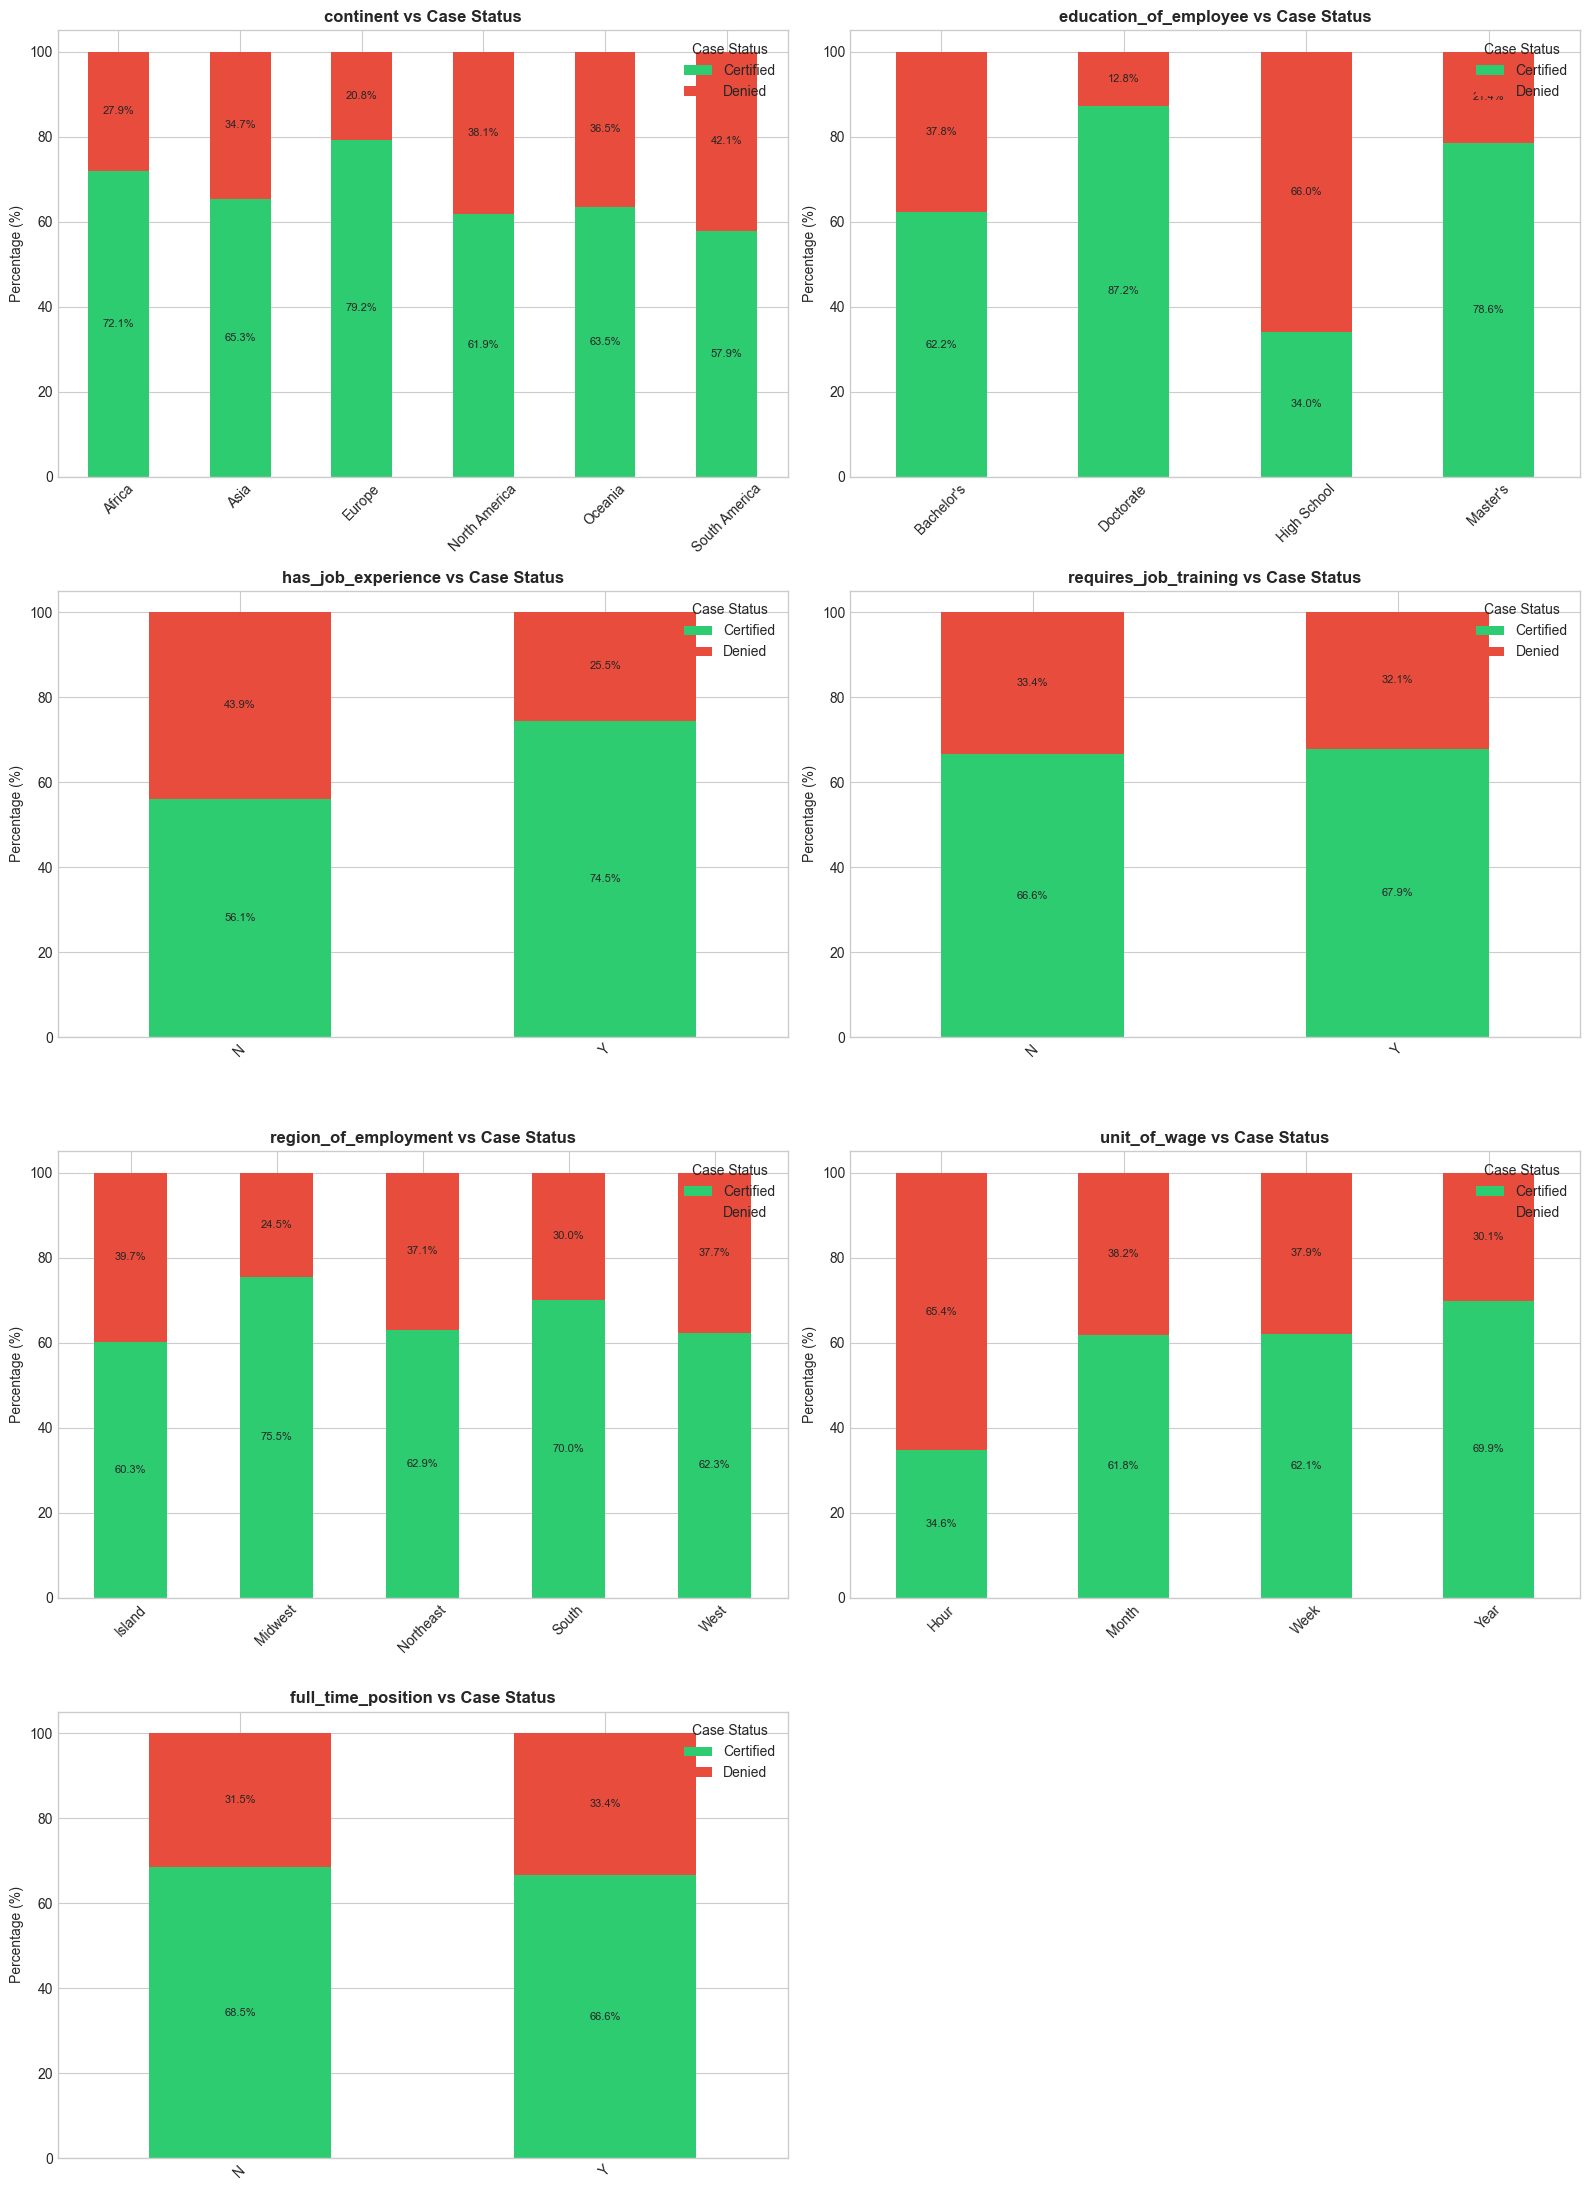

In [18]:
# Bivariate analysis: Categorical variables vs Target
fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()

for idx, col in enumerate(cat_cols_analysis):
    # Stacked bar chart
    cross_tab = pd.crosstab(data[col], data['case_status'], normalize='index') * 100
    cross_tab.plot(kind='bar', stacked=True, ax=axes[idx], color=['#2ecc71', '#e74c3c'])
    axes[idx].set_title(f'{col} vs Case Status', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Percentage (%)')
    axes[idx].legend(title='Case Status', loc='upper right')
    axes[idx].tick_params(axis='x', rotation=45)
    
    # Add percentage labels
    for container in axes[idx].containers:
        axes[idx].bar_label(container, fmt='%.1f%%', label_type='center', fontsize=8)

if len(cat_cols_analysis) < len(axes):
    for idx in range(len(cat_cols_analysis), len(axes)):
        fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

In [19]:
# Detailed cross-tabulation with percentages
print("Cross-tabulation Analysis:")
print("=" * 70)

for col in cat_cols_analysis:
    print(f"\n{col.upper()} vs CASE_STATUS:")
    cross_tab = pd.crosstab(data[col], data['case_status'], margins=True)
    cross_tab_pct = pd.crosstab(data[col], data['case_status'], normalize='index') * 100
    
    result = pd.concat([cross_tab, cross_tab_pct.add_suffix(' (%)').round(2)], axis=1)
    display(result)

Cross-tabulation Analysis:

CONTINENT vs CASE_STATUS:


case_status,Certified,Denied,All,Certified (%),Denied (%)
continent,,,,,
Africa,397,154,551,72.050,27.950
Asia,11012,5849,16861,65.310,34.690
Europe,2957,775,3732,79.230,20.770
North America,2037,1255,3292,61.880,38.120
Oceania,122,70,192,63.540,36.460
South America,493,359,852,57.860,42.140
All,17018,8462,25480,NaN,NaN



EDUCATION_OF_EMPLOYEE vs CASE_STATUS:


case_status,Certified,Denied,All,Certified (%),Denied (%)
education_of_employee,,,,,
Bachelor's,6367,3867,10234,62.210,37.790
Doctorate,1912,280,2192,87.230,12.770
High School,1164,2256,3420,34.040,65.960
Master's,7575,2059,9634,78.630,21.370
All,17018,8462,25480,NaN,NaN



HAS_JOB_EXPERIENCE vs CASE_STATUS:


...

case_status,Certified,Denied,All,Certified (%),Denied (%)
region_of_employment,,,,,
Island,226,149,375,60.270,39.730
Midwest,3253,1054,4307,75.530,24.470
Northeast,4526,2669,7195,62.900,37.100
South,4913,2104,7017,70.020,29.980
West,4100,2486,6586,62.250,37.750
All,17018,8462,25480,NaN,NaN



UNIT_OF_WAGE vs CASE_STATUS:


case_status,Certified,Denied,All,Certified (%),Denied (%)
unit_of_wage,,,,,
Hour,747,1410,2157,34.630,65.370
Month,55,34,89,61.800,38.200
Week,169,103,272,62.130,37.870
Year,16047,6915,22962,69.890,30.110
All,17018,8462,25480,NaN,NaN



FULL_TIME_POSITION vs CASE_STATUS:


case_status,Certified,Denied,All,Certified (%),Denied (%)
full_time_position,,,,,
N,1855,852,2707,68.530,31.470
Y,15163,7610,22773,66.580,33.420
All,17018,8462,25480,NaN,NaN


**Key Observations - Bivariate Analysis (Categorical vs Target):**

1. **Continent**: Asia has highest denial rate, while Europe and North America have relatively higher approval rates
2. **Education**: Higher education (Master's, Doctorate) leads to higher approval rates. High School education has highest denial rate.
3. **Job Experience**: Applicants with job experience have significantly higher approval rates
4. **Job Training**: Applicants requiring job training have slightly lower approval rates
5. **Full-time Position**: Full-time positions have higher approval rates than part-time
6. **Region of Employment**: Some regional variations exist, with South having slightly higher approvals

### 2.6 Bivariate Analysis - Numerical vs Target

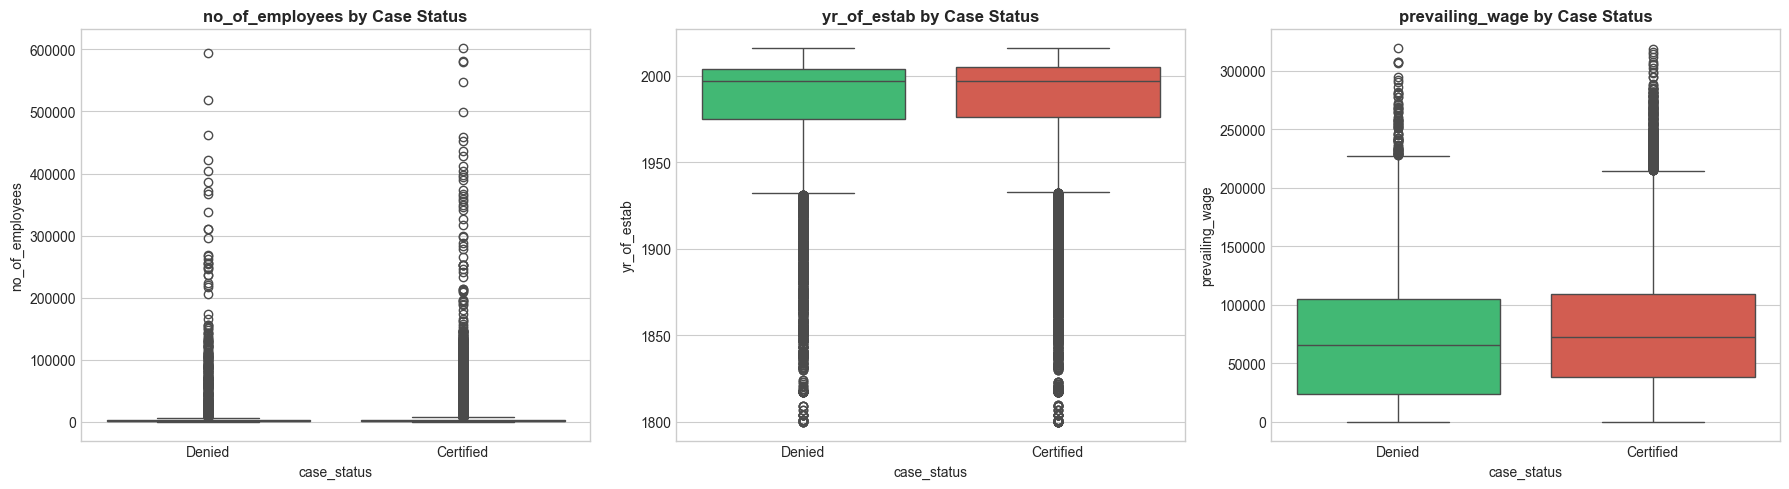

In [20]:
# Numerical variables vs Target - Box plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(numerical_cols):
    sns.boxplot(data=data, x='case_status', y=col, ax=axes[idx], palette=['#2ecc71', '#e74c3c'])
    axes[idx].set_title(f'{col} by Case Status', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

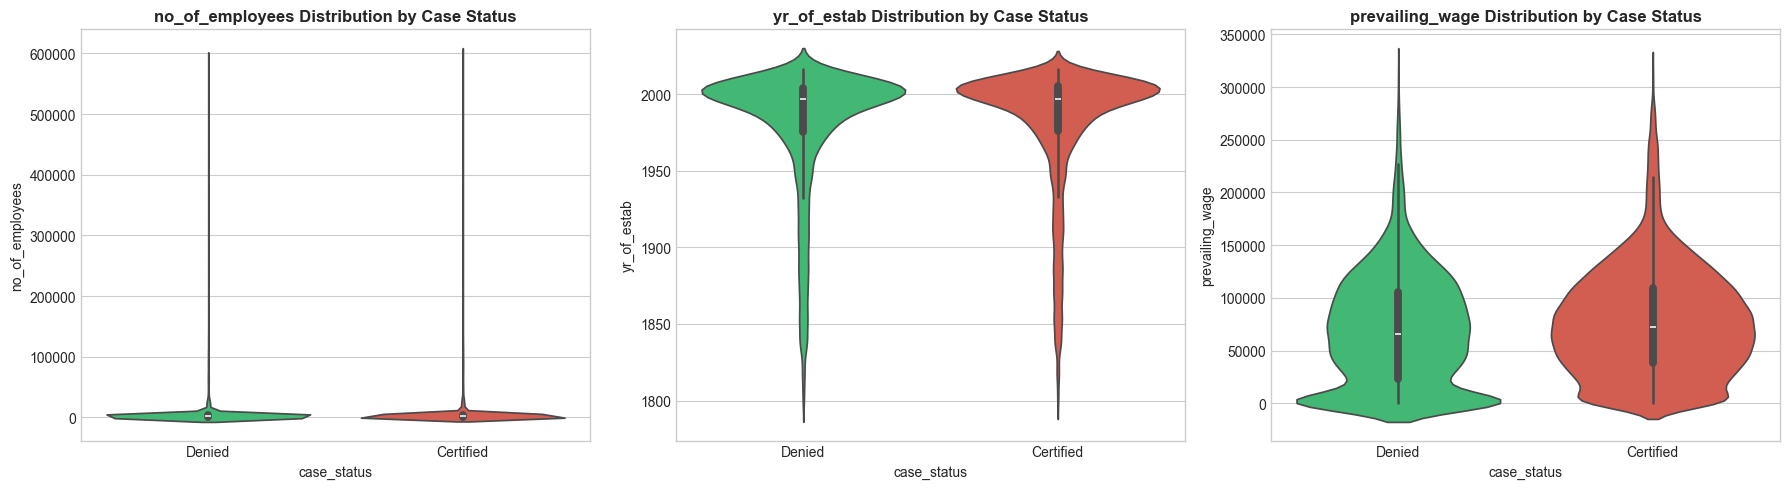

In [21]:
# Distribution comparison using violin plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(numerical_cols):
    sns.violinplot(data=data, x='case_status', y=col, ax=axes[idx], palette=['#2ecc71', '#e74c3c'])
    axes[idx].set_title(f'{col} Distribution by Case Status', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [22]:
# Statistical comparison by target
print("Numerical Features Statistics by Case Status:")
print("=" * 70)

for col in numerical_cols:
    print(f"\n{col.upper()}:")
    stats = data.groupby('case_status')[col].agg(['mean', 'median', 'std', 'min', 'max'])
    display(stats.round(2))

Numerical Features Statistics by Case Status:

NO_OF_EMPLOYEES:


,mean,median,std,min,max
case_status,,,,,
Certified,5807.020,2147.000,23119.580,-26,602069
Denied,5385.540,2032.500,22382.760,-26,594472



YR_OF_ESTAB:


,mean,median,std,min,max
case_status,,,,,
Certified,1979.670,1997.000,42.280,1800,2016
Denied,1978.890,1997.000,42.540,1800,2016



PREVAILING_WAGE:


,mean,median,std,min,max
case_status,,,,,
Certified,77293.620,72486.270,52042.720,2.140,318446.050
Denied,68748.680,65431.460,53890.170,2.960,319210.270


### 2.7 Correlation Analysis

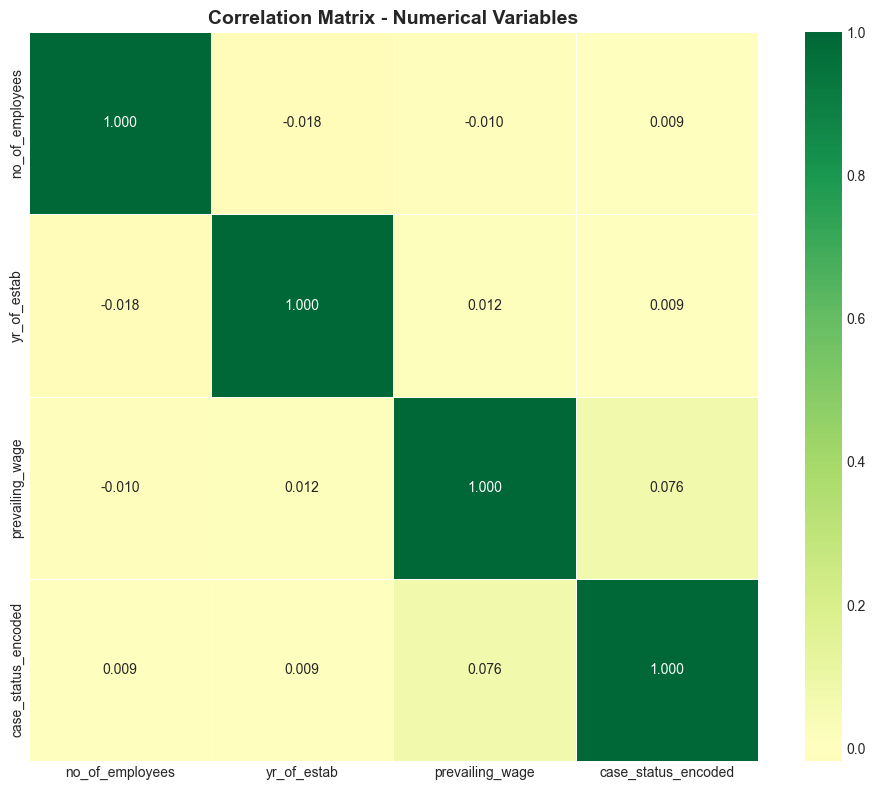


Correlation with Target (case_status):
case_status_encoded   1.000
prevailing_wage       0.076
no_of_employees       0.009
yr_of_estab           0.009
Name: case_status_encoded, dtype: float64


In [23]:
# Encode target for correlation
data_corr = data.copy()
data_corr['case_status_encoded'] = (data_corr['case_status'] == 'Certified').astype(int)

# Correlation heatmap for numerical variables
corr_cols = numerical_cols + ['case_status_encoded']
correlation_matrix = data_corr[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0, 
            fmt='.3f', linewidths=0.5, square=True)
plt.title('Correlation Matrix - Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation with Target (case_status):")
print(correlation_matrix['case_status_encoded'].sort_values(ascending=False))

### 2.8 Unit of Wage Analysis

In [24]:
# Analyze prevailing_wage by unit_of_wage
print("Prevailing Wage Statistics by Unit of Wage:")
print("=" * 70)

wage_stats = data.groupby('unit_of_wage')['prevailing_wage'].agg(['count', 'mean', 'median', 'min', 'max'])
display(wage_stats.round(2))

Prevailing Wage Statistics by Unit of Wage:


,count,mean,median,min,max
unit_of_wage,,,,,
Hour,2157,414.570,372.650,2.140,999.920
Month,89,87592.860,81826.010,1599.280,264362.950
Week,272,85606.820,85075.820,2183.230,280175.950
Year,22962,81228.080,76174.500,100.000,319210.270


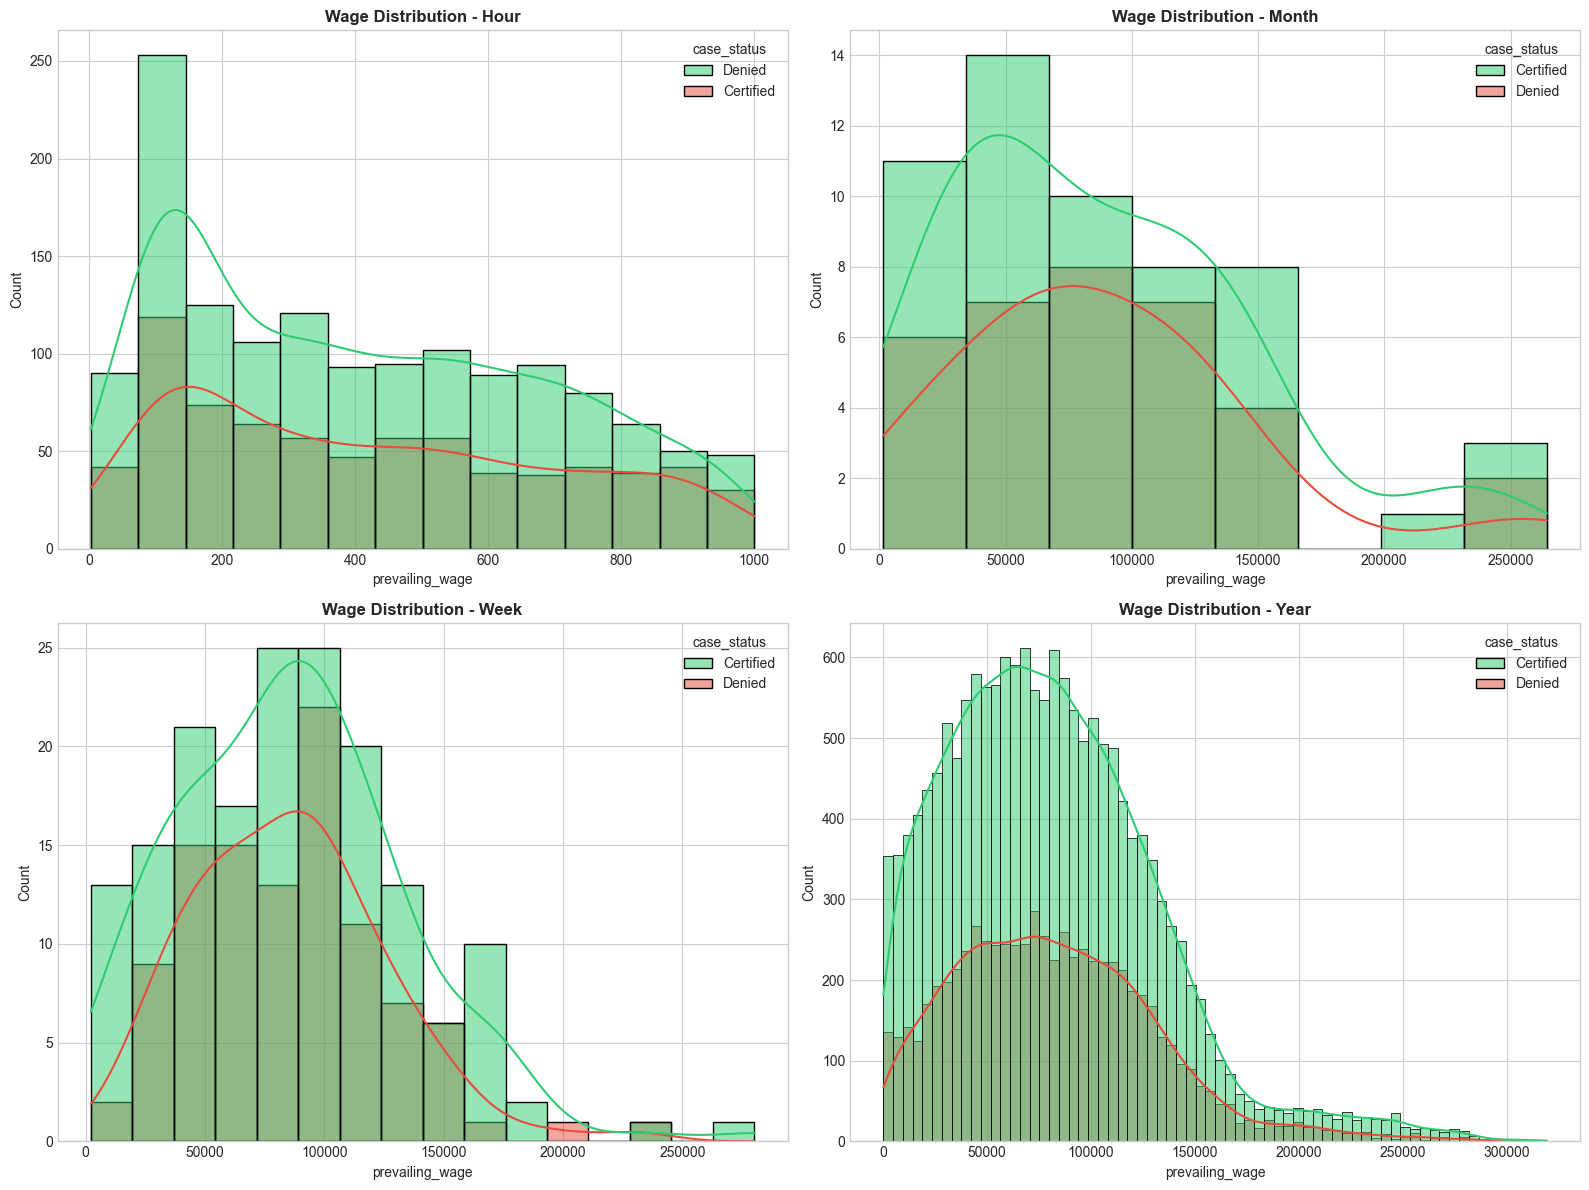

In [25]:
# Visualize wage distribution by unit
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, (unit, group) in enumerate(data.groupby('unit_of_wage')):
    row, col = divmod(idx, 2)
    sns.histplot(data=group, x='prevailing_wage', hue='case_status', kde=True,
                 ax=axes[row, col], palette=['#2ecc71', '#e74c3c'])
    axes[row, col].set_title(f'Wage Distribution - {unit}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 2.9 EDA Summary and Key Insights

**Dataset Overview:**
- Total records: ~25,480 visa applications
- 11 features + 1 target variable
- No missing values detected
- Target is imbalanced (~67% Certified, ~33% Denied)

**Key Patterns Identified:**

1. **Education is a strong predictor**: Higher education levels correlate with higher approval rates
2. **Job experience matters**: Applicants with job experience have significantly better chances of approval
3. **Full-time positions preferred**: Full-time positions have higher approval rates
4. **Continental patterns**: Asian applicants have higher denial rates compared to European/North American
5. **Company size variation**: Wide range of employer company sizes from startups to large corporations
6. **Wage variations**: Prevailing wage varies significantly across different units and job types

---
## 3. Data Pre-processing

### 3.1 Data Cleaning

In [26]:
# Create a clean copy for modeling
df_clean = data.copy()

# Drop case_id as it's just an identifier
df_clean = df_clean.drop('case_id', axis=1)

print(f"Shape after removing case_id: {df_clean.shape}")
print(f"\nColumns: {df_clean.columns.tolist()}")

Shape after removing case_id: (25480, 11)

Columns: ['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'no_of_employees', 'yr_of_estab', 'region_of_employment', 'prevailing_wage', 'unit_of_wage', 'full_time_position', 'case_status']


### 3.2 Feature Engineering

In [27]:
# Feature Engineering 1: Convert wage to annual equivalent
def convert_to_annual_wage(row):
    """
    Convert prevailing wage to annual equivalent based on unit_of_wage.
    Assumptions:
    - Hourly: 40 hours/week * 52 weeks = 2080 hours/year
    - Weekly: 52 weeks/year
    - Monthly: 12 months/year
    - Yearly: Already annual
    """
    wage = row['prevailing_wage']
    unit = row['unit_of_wage']
    
    if unit == 'Hour':
        return wage * 2080
    elif unit == 'Week':
        return wage * 52
    elif unit == 'Month':
        return wage * 12
    else:  # Year
        return wage

df_clean['annual_wage'] = df_clean.apply(convert_to_annual_wage, axis=1)

print("Annual Wage Statistics:")
print(df_clean['annual_wage'].describe())

Annual Wage Statistics:
count      25480.000
mean      197391.155
std       578591.666
min          100.000
25%        47107.965
50%        82839.460
75%       124825.035
max     14569149.400
Name: annual_wage, dtype: float64


In [28]:
# Feature Engineering 2: Company Age
current_year = 2016  # Based on the data context (FY 2016)
df_clean['company_age'] = current_year - df_clean['yr_of_estab']

print("Company Age Statistics:")
print(df_clean['company_age'].describe())

Company Age Statistics:
count   25480.000
mean       36.590
std        42.367
min         0.000
25%        11.000
50%        19.000
75%        40.000
max       216.000
Name: company_age, dtype: float64


In [29]:
# Handle negative company ages (companies established after 2016 - data quality issue)
print(f"\nCompanies with negative age: {(df_clean['company_age'] < 0).sum()}")

# Set negative ages to 0 (newly established)
df_clean.loc[df_clean['company_age'] < 0, 'company_age'] = 0

print(f"Company age range after correction: [{df_clean['company_age'].min()}, {df_clean['company_age'].max()}]")


Companies with negative age: 0
Company age range after correction: [0, 216]


In [30]:
# Feature Engineering 3: Wage Category based on annual wage
def categorize_wage(wage):
    if wage < 40000:
        return 'Low'
    elif wage < 80000:
        return 'Medium'
    elif wage < 150000:
        return 'High'
    else:
        return 'Very High'

df_clean['wage_category'] = df_clean['annual_wage'].apply(categorize_wage)

print("Wage Category Distribution:")
print(df_clean['wage_category'].value_counts())

Wage Category Distribution:
wage_category
High         9091
Medium       7091
Low          5109
Very High    4189
Name: count, dtype: int64


In [31]:
# Feature Engineering 4: Company Size Category
def categorize_company_size(employees):
    if employees < 50:
        return 'Small'
    elif employees < 500:
        return 'Medium'
    elif employees < 5000:
        return 'Large'
    else:
        return 'Enterprise'

df_clean['company_size'] = df_clean['no_of_employees'].apply(categorize_company_size)

print("Company Size Distribution:")
print(df_clean['company_size'].value_counts())

Company Size Distribution:
company_size
Large         19750
Medium         2848
Enterprise     2640
Small           242
Name: count, dtype: int64


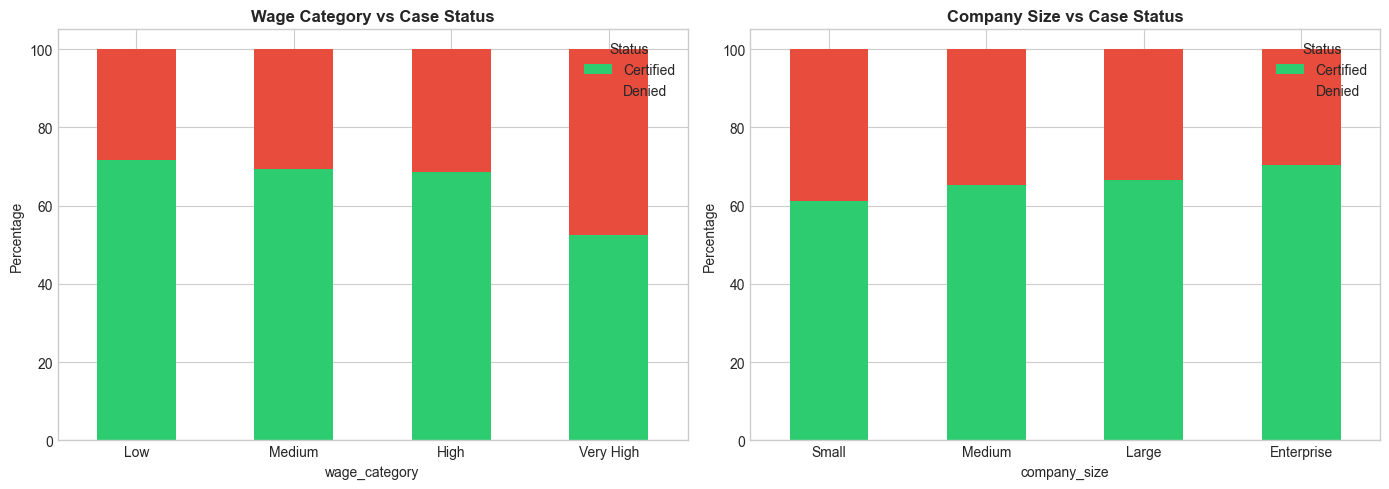

In [32]:
# Visualize new features vs target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wage Category vs Target
order1 = ['Low', 'Medium', 'High', 'Very High']
ct1 = pd.crosstab(df_clean['wage_category'], df_clean['case_status'], normalize='index') * 100
ct1.loc[order1].plot(kind='bar', stacked=True, ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Wage Category vs Case Status', fontweight='bold')
axes[0].set_ylabel('Percentage')
axes[0].legend(title='Status')
axes[0].tick_params(axis='x', rotation=0)

# Company Size vs Target
order2 = ['Small', 'Medium', 'Large', 'Enterprise']
ct2 = pd.crosstab(df_clean['company_size'], df_clean['case_status'], normalize='index') * 100
ct2.loc[order2].plot(kind='bar', stacked=True, ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Company Size vs Case Status', fontweight='bold')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='Status')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 3.3 Outlier Treatment

In [33]:
# Outlier Treatment using IQR method with capping
def cap_outliers_iqr(df, column, lower_percentile=0.01, upper_percentile=0.99):
    """
    Cap outliers at specified percentiles to preserve data while reducing extreme values.
    """
    lower_bound = df[column].quantile(lower_percentile)
    upper_bound = df[column].quantile(upper_percentile)
    
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    
    return df, lower_bound, upper_bound

# Apply outlier treatment to numerical features
outlier_cols = ['no_of_employees', 'annual_wage', 'company_age']

print("Outlier Treatment Summary:")
print("=" * 60)

for col in outlier_cols:
    original_min, original_max = df_clean[col].min(), df_clean[col].max()
    df_clean, lb, ub = cap_outliers_iqr(df_clean, col)
    print(f"\n{col}:")
    print(f"  Original Range: [{original_min:.2f}, {original_max:.2f}]")
    print(f"  After Capping: [{lb:.2f}, {ub:.2f}]")

Outlier Treatment Summary:

no_of_employees:
  Original Range: [-26.00, 602069.00]
  After Capping: [52.00, 102767.00]

annual_wage:
  Original Range: [100.00, 14569149.40]
  After Capping: [2633.59, 2036027.16]

company_age:
  Original Range: [0.00, 216.00]
  After Capping: [2.00, 179.00]


### 3.4 Encoding Categorical Variables

In [34]:
# Check current columns
print("Current DataFrame columns:")
print(df_clean.columns.tolist())
print(f"\nShape: {df_clean.shape}")

Current DataFrame columns:
['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'no_of_employees', 'yr_of_estab', 'region_of_employment', 'prevailing_wage', 'unit_of_wage', 'full_time_position', 'case_status', 'annual_wage', 'company_age', 'wage_category', 'company_size']

Shape: (25480, 15)


In [35]:
# Identify final features for modeling
# We'll drop redundant columns and keep engineered features

# Drop original columns that have been transformed/engineered
columns_to_drop = ['prevailing_wage', 'unit_of_wage', 'yr_of_estab']
df_model = df_clean.drop(columns=columns_to_drop)

print("Columns for modeling:")
print(df_model.columns.tolist())
print(f"\nShape: {df_model.shape}")

Columns for modeling:
['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'no_of_employees', 'region_of_employment', 'full_time_position', 'case_status', 'annual_wage', 'company_age', 'wage_category', 'company_size']

Shape: (25480, 12)


In [36]:
# Encode binary categorical variables
binary_mapping = {'Y': 1, 'N': 0}

df_model['has_job_experience'] = df_model['has_job_experience'].map(binary_mapping)
df_model['requires_job_training'] = df_model['requires_job_training'].map(binary_mapping)
df_model['full_time_position'] = df_model['full_time_position'].map(binary_mapping)

# Encode target variable
df_model['case_status'] = df_model['case_status'].map({'Certified': 1, 'Denied': 0})

print("Binary encoding completed.")
df_model.head()

Binary encoding completed.


,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,full_time_position,case_status,annual_wage,company_age,wage_category,company_size
0,Asia,High School,0,0,14513.000,West,1,0,1231782.032,9,Very High,Enterprise
1,Asia,Master's,1,0,2412.000,Northeast,1,1,83425.650,14,High,Large
2,Asia,Bachelor's,0,1,44444.000,West,1,0,122996.860,8,High,Enterprise
3,Asia,Bachelor's,0,0,98.000,West,1,0,83434.030,119,High,Medium
4,Africa,Master's,1,0,1082.000,South,1,1,149907.390,11,High,Large


In [37]:
# One-hot encode multi-category columns
multi_cat_cols = ['continent', 'education_of_employee', 'region_of_employment', 'wage_category', 'company_size']

df_encoded = pd.get_dummies(df_model, columns=multi_cat_cols, drop_first=True, dtype=int)

print(f"Shape after encoding: {df_encoded.shape}")
print(f"\nColumns ({len(df_encoded.columns)}):")
print(df_encoded.columns.tolist())

Shape after encoding: (25480, 25)

Columns (25):
['has_job_experience', 'requires_job_training', 'no_of_employees', 'full_time_position', 'case_status', 'annual_wage', 'company_age', 'continent_Asia', 'continent_Europe', 'continent_North America', 'continent_Oceania', 'continent_South America', 'education_of_employee_Doctorate', 'education_of_employee_High School', "education_of_employee_Master's", 'region_of_employment_Midwest', 'region_of_employment_Northeast', 'region_of_employment_South', 'region_of_employment_West', 'wage_category_Low', 'wage_category_Medium', 'wage_category_Very High', 'company_size_Large', 'company_size_Medium', 'company_size_Small']


In [38]:
# Final encoded dataframe
df_encoded.head()

,has_job_experience,requires_job_training,no_of_employees,full_time_position,case_status,annual_wage,company_age,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,education_of_employee_Doctorate,education_of_employee_High School,education_of_employee_Master's,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,wage_category_Low,wage_category_Medium,wage_category_Very High,company_size_Large,company_size_Medium,company_size_Small
0,0,0,14513.000,1,0,1231782.032,9,1,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0
1,1,0,2412.000,1,1,83425.650,14,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0
2,0,1,44444.000,1,0,122996.860,8,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,0,0,98.000,1,0,83434.030,119,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
4,1,0,1082.000,1,1,149907.390,11,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0


### 3.5 Train-Test Split

In [39]:
# Separate features and target
X = df_encoded.drop('case_status', axis=1)
y = df_encoded['case_status']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())

Features shape: (25480, 24)
Target shape: (25480,)

Target distribution:
case_status
1    17018
0     8462
Name: count, dtype: int64


In [40]:
# Split data into train and test sets (70-30 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

print("Train-Test Split Summary:")
print("=" * 50)
print(f"Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Train-Test Split Summary:
Training set: 17,836 samples (70.0%)
Test set: 7,644 samples (30.0%)

Training target distribution:
case_status
1   0.668
0   0.332
Name: proportion, dtype: float64

Test target distribution:
case_status
1   0.668
0   0.332
Name: proportion, dtype: float64


### 3.6 Prepare Resampled Data

In [41]:
# Create oversampled training data using SMOTE
smote = SMOTE(random_state=42)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

print("Oversampled Training Data (SMOTE):")
print("=" * 50)
print(f"Original training samples: {len(y_train):,}")
print(f"Oversampled training samples: {len(y_train_over):,}")
print(f"\nOversampled target distribution:")
print(pd.Series(y_train_over).value_counts())

Oversampled Training Data (SMOTE):
Original training samples: 17,836
Oversampled training samples: 23,826

Oversampled target distribution:
case_status
0    11913
1    11913
Name: count, dtype: int64


In [42]:
# Create undersampled training data
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("Undersampled Training Data:")
print("=" * 50)
print(f"Original training samples: {len(y_train):,}")
print(f"Undersampled training samples: {len(y_train_under):,}")
print(f"\nUndersampled target distribution:")
print(pd.Series(y_train_under).value_counts())

Undersampled Training Data:
Original training samples: 17,836
Undersampled training samples: 11,846

Undersampled target distribution:
case_status
0    5923
1    5923
Name: count, dtype: int64


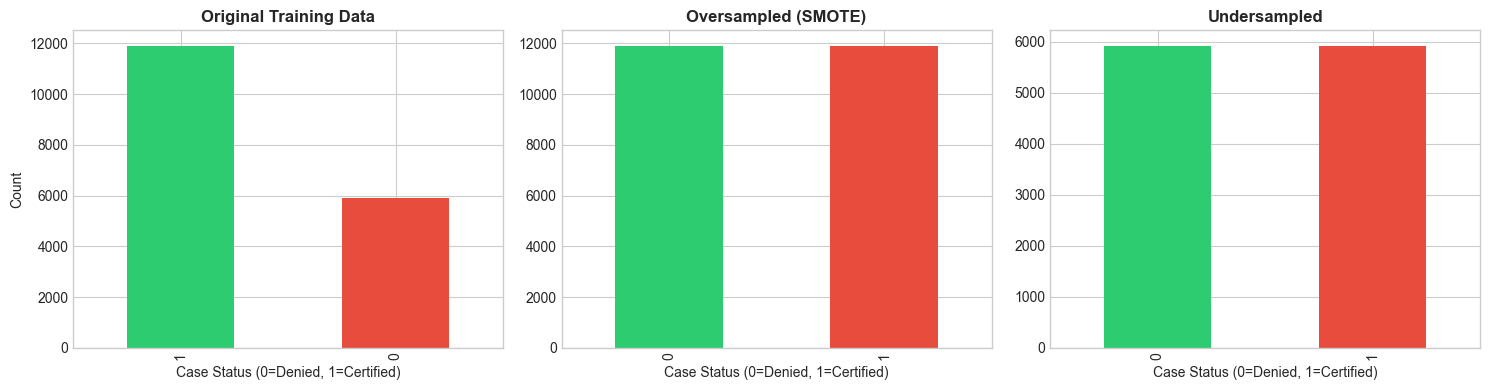

In [43]:
# Visualize the resampling results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original
y_train.value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Original Training Data', fontweight='bold')
axes[0].set_xlabel('Case Status (0=Denied, 1=Certified)')
axes[0].set_ylabel('Count')

# Oversampled
pd.Series(y_train_over).value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Oversampled (SMOTE)', fontweight='bold')
axes[1].set_xlabel('Case Status (0=Denied, 1=Certified)')

# Undersampled
pd.Series(y_train_under).value_counts().plot(kind='bar', ax=axes[2], color=['#2ecc71', '#e74c3c'])
axes[2].set_title('Undersampled', fontweight='bold')
axes[2].set_xlabel('Case Status (0=Denied, 1=Certified)')

plt.tight_layout()
plt.show()

---
## 4. Model Building - Original Data

In [44]:
# Helper function to evaluate models
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """
    Train and evaluate a classification model.
    Returns a dictionary of metrics.
    """
    # Train the model
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Probabilities for ROC-AUC
    if hasattr(model, 'predict_proba'):
        y_train_proba = model.predict_proba(X_train)[:, 1]
        y_test_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_train_proba = y_train_pred
        y_test_proba = y_test_pred
    
    # Calculate metrics
    metrics = {
        'Model': model_name,
        'Train_Accuracy': accuracy_score(y_train, y_train_pred),
        'Test_Accuracy': accuracy_score(y_test, y_test_pred),
        'Test_Precision': precision_score(y_test, y_test_pred),
        'Test_Recall': recall_score(y_test, y_test_pred),
        'Test_F1': f1_score(y_test, y_test_pred),
        'Test_ROC_AUC': roc_auc_score(y_test, y_test_proba)
    }
    
    return metrics, model

# Function to display results
def display_model_results(metrics, model, X_test, y_test, model_name):
    """
    Display model evaluation results with confusion matrix and classification report.
    """
    print(f"\n{'='*60}")
    print(f"{model_name} Results")
    print(f"{'='*60}")
    
    y_pred = model.predict(X_test)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Denied', 'Certified'], 
                yticklabels=['Denied', 'Certified'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Denied', 'Certified']))
    
    # Metrics Summary
    print("\nMetrics Summary:")
    for key, value in metrics.items():
        if key != 'Model':
            print(f"  {key}: {value:.4f}")

In [45]:
# Dictionary to store all results
results_original = []
trained_models_original = {}

### 4.1 Decision Tree Classifier


Decision Tree Results


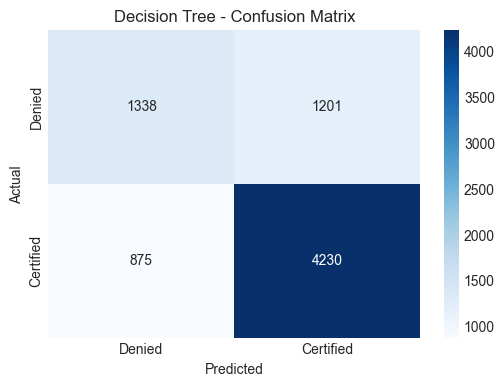


Classification Report:
              precision    recall  f1-score   support

      Denied       0.60      0.53      0.56      2539
   Certified       0.78      0.83      0.80      5105

    accuracy                           0.73      7644
   macro avg       0.69      0.68      0.68      7644
weighted avg       0.72      0.73      0.72      7644


Metrics Summary:
  Train_Accuracy: 0.7757
  Test_Accuracy: 0.7284
  Test_Precision: 0.7789
  Test_Recall: 0.8286
  Test_F1: 0.8030
  Test_ROC_AUC: 0.7390


In [46]:
# Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_metrics, dt_trained = evaluate_model(dt_model, X_train, y_train, X_test, y_test, 'Decision Tree')
results_original.append(dt_metrics)
trained_models_original['Decision Tree'] = dt_trained

display_model_results(dt_metrics, dt_trained, X_test, y_test, 'Decision Tree')

### 4.2 Random Forest Classifier


Random Forest Results


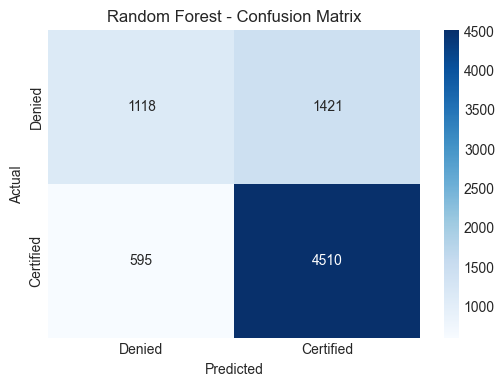


Classification Report:
              precision    recall  f1-score   support

      Denied       0.65      0.44      0.53      2539
   Certified       0.76      0.88      0.82      5105

    accuracy                           0.74      7644
   macro avg       0.71      0.66      0.67      7644
weighted avg       0.72      0.74      0.72      7644


Metrics Summary:
  Train_Accuracy: 0.7807
  Test_Accuracy: 0.7363
  Test_Precision: 0.7604
  Test_Recall: 0.8834
  Test_F1: 0.8173
  Test_ROC_AUC: 0.7702


In [47]:
# Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, n_jobs=-1)
rf_metrics, rf_trained = evaluate_model(rf_model, X_train, y_train, X_test, y_test, 'Random Forest')
results_original.append(rf_metrics)
trained_models_original['Random Forest'] = rf_trained

display_model_results(rf_metrics, rf_trained, X_test, y_test, 'Random Forest')

### 4.3 Bagging Classifier


Bagging Results


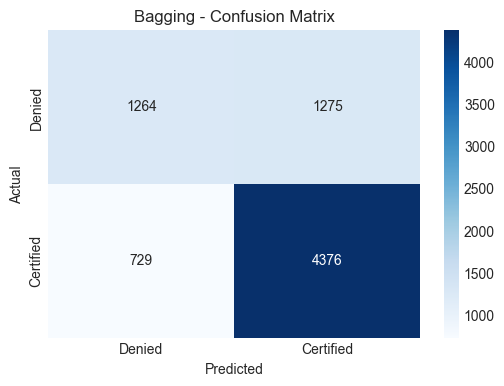


Classification Report:
              precision    recall  f1-score   support

      Denied       0.63      0.50      0.56      2539
   Certified       0.77      0.86      0.81      5105

    accuracy                           0.74      7644
   macro avg       0.70      0.68      0.69      7644
weighted avg       0.73      0.74      0.73      7644


Metrics Summary:
  Train_Accuracy: 0.7869
  Test_Accuracy: 0.7378
  Test_Precision: 0.7744
  Test_Recall: 0.8572
  Test_F1: 0.8137
  Test_ROC_AUC: 0.7676


In [48]:
# Bagging Classifier
bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=10),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)
bag_metrics, bag_trained = evaluate_model(bag_model, X_train, y_train, X_test, y_test, 'Bagging')
results_original.append(bag_metrics)
trained_models_original['Bagging'] = bag_trained

display_model_results(bag_metrics, bag_trained, X_test, y_test, 'Bagging')

### 4.4 AdaBoost Classifier


AdaBoost Results


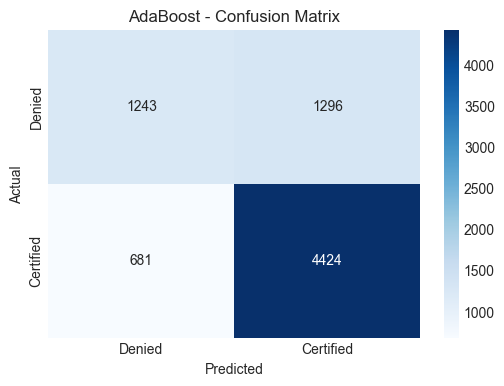


Classification Report:
              precision    recall  f1-score   support

      Denied       0.65      0.49      0.56      2539
   Certified       0.77      0.87      0.82      5105

    accuracy                           0.74      7644
   macro avg       0.71      0.68      0.69      7644
weighted avg       0.73      0.74      0.73      7644


Metrics Summary:
  Train_Accuracy: 0.7544
  Test_Accuracy: 0.7414
  Test_Precision: 0.7734
  Test_Recall: 0.8666
  Test_F1: 0.8174
  Test_ROC_AUC: 0.7732


In [49]:
# AdaBoost Classifier
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=5),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
ada_metrics, ada_trained = evaluate_model(ada_model, X_train, y_train, X_test, y_test, 'AdaBoost')
results_original.append(ada_metrics)
trained_models_original['AdaBoost'] = ada_trained

display_model_results(ada_metrics, ada_trained, X_test, y_test, 'AdaBoost')

### 4.5 Gradient Boosting Classifier


Gradient Boosting Results


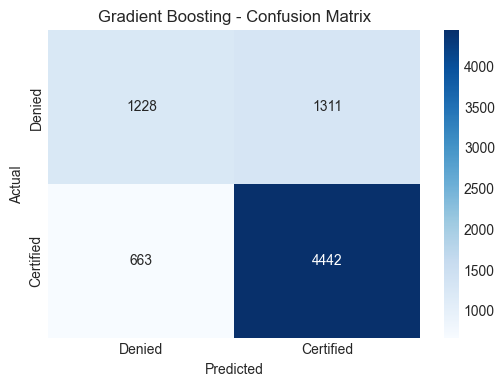


Classification Report:
              precision    recall  f1-score   support

      Denied       0.65      0.48      0.55      2539
   Certified       0.77      0.87      0.82      5105

    accuracy                           0.74      7644
   macro avg       0.71      0.68      0.69      7644
weighted avg       0.73      0.74      0.73      7644


Metrics Summary:
  Train_Accuracy: 0.7798
  Test_Accuracy: 0.7418
  Test_Precision: 0.7721
  Test_Recall: 0.8701
  Test_F1: 0.8182
  Test_ROC_AUC: 0.7721


In [50]:
# Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb_metrics, gb_trained = evaluate_model(gb_model, X_train, y_train, X_test, y_test, 'Gradient Boosting')
results_original.append(gb_metrics)
trained_models_original['Gradient Boosting'] = gb_trained

display_model_results(gb_metrics, gb_trained, X_test, y_test, 'Gradient Boosting')

### 4.6 Original Data - Model Comparison

In [51]:
# Create summary dataframe for original data models
results_df_original = pd.DataFrame(results_original)
results_df_original = results_df_original.set_index('Model')
results_df_original = results_df_original.round(4)

print("Model Comparison - Original Data:")
print("=" * 80)
display(results_df_original)

Model Comparison - Original Data:


,Train_Accuracy,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
Model,,,,,,
Decision Tree,0.776,0.728,0.779,0.829,0.803,0.739
Random Forest,0.781,0.736,0.760,0.883,0.817,0.770
Bagging,0.787,0.738,0.774,0.857,0.814,0.768
AdaBoost,0.754,0.741,0.773,0.867,0.817,0.773
Gradient Boosting,0.780,0.742,0.772,0.870,0.818,0.772


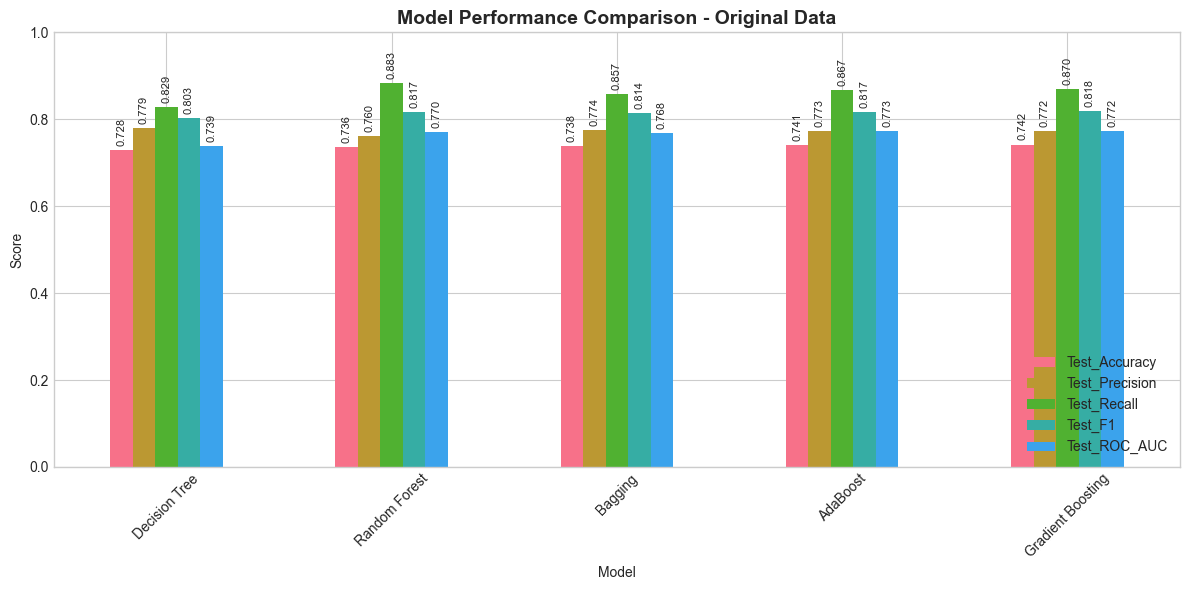

In [52]:
# Visualize model comparison
metrics_to_plot = ['Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_F1', 'Test_ROC_AUC']

fig, ax = plt.subplots(figsize=(12, 6))
results_df_original[metrics_to_plot].plot(kind='bar', ax=ax)
ax.set_title('Model Performance Comparison - Original Data', fontsize=14, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_ylim([0, 1])
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=45)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, rotation=90, padding=3)

plt.tight_layout()
plt.show()

---
## 5. Model Building - Oversampled Data (SMOTE)

In [53]:
# Dictionary to store oversampled results
results_oversampled = []
trained_models_oversampled = {}

### 5.1 Decision Tree - Oversampled


Decision Tree (SMOTE) Results


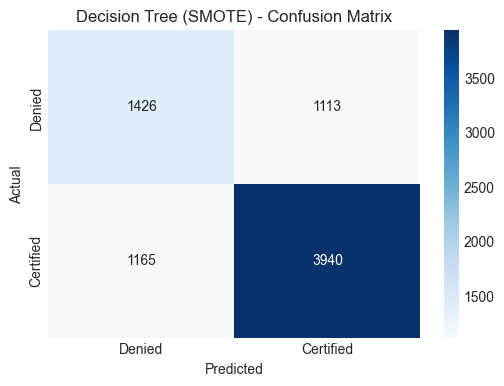


Classification Report:
              precision    recall  f1-score   support

      Denied       0.55      0.56      0.56      2539
   Certified       0.78      0.77      0.78      5105

    accuracy                           0.70      7644
   macro avg       0.67      0.67      0.67      7644
weighted avg       0.70      0.70      0.70      7644


Metrics Summary:
  Train_Accuracy: 0.8127
  Test_Accuracy: 0.7020
  Test_Precision: 0.7797
  Test_Recall: 0.7718
  Test_F1: 0.7757
  Test_ROC_AUC: 0.7298


In [54]:
# Decision Tree on Oversampled Data
dt_over_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_over_metrics, dt_over_trained = evaluate_model(dt_over_model, X_train_over, y_train_over, X_test, y_test, 'Decision Tree (SMOTE)')
results_oversampled.append(dt_over_metrics)
trained_models_oversampled['Decision Tree'] = dt_over_trained

display_model_results(dt_over_metrics, dt_over_trained, X_test, y_test, 'Decision Tree (SMOTE)')

### 5.2 Random Forest - Oversampled


Random Forest (SMOTE) Results


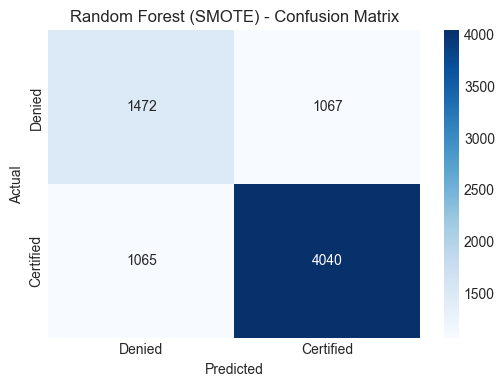


Classification Report:
              precision    recall  f1-score   support

      Denied       0.58      0.58      0.58      2539
   Certified       0.79      0.79      0.79      5105

    accuracy                           0.72      7644
   macro avg       0.69      0.69      0.69      7644
weighted avg       0.72      0.72      0.72      7644


Metrics Summary:
  Train_Accuracy: 0.8194
  Test_Accuracy: 0.7211
  Test_Precision: 0.7911
  Test_Recall: 0.7914
  Test_F1: 0.7912
  Test_ROC_AUC: 0.7627


In [55]:
# Random Forest on Oversampled Data
rf_over_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, n_jobs=-1)
rf_over_metrics, rf_over_trained = evaluate_model(rf_over_model, X_train_over, y_train_over, X_test, y_test, 'Random Forest (SMOTE)')
results_oversampled.append(rf_over_metrics)
trained_models_oversampled['Random Forest'] = rf_over_trained

display_model_results(rf_over_metrics, rf_over_trained, X_test, y_test, 'Random Forest (SMOTE)')

### 5.3 Bagging - Oversampled


Bagging (SMOTE) Results


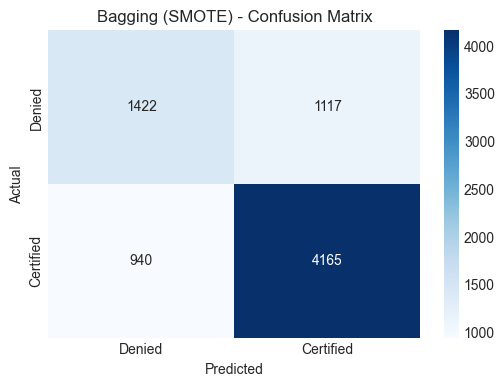


Classification Report:
              precision    recall  f1-score   support

      Denied       0.60      0.56      0.58      2539
   Certified       0.79      0.82      0.80      5105

    accuracy                           0.73      7644
   macro avg       0.70      0.69      0.69      7644
weighted avg       0.73      0.73      0.73      7644


Metrics Summary:
  Train_Accuracy: 0.8280
  Test_Accuracy: 0.7309
  Test_Precision: 0.7885
  Test_Recall: 0.8159
  Test_F1: 0.8020
  Test_ROC_AUC: 0.7590


In [56]:
# Bagging on Oversampled Data
bag_over_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=10),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)
bag_over_metrics, bag_over_trained = evaluate_model(bag_over_model, X_train_over, y_train_over, X_test, y_test, 'Bagging (SMOTE)')
results_oversampled.append(bag_over_metrics)
trained_models_oversampled['Bagging'] = bag_over_trained

display_model_results(bag_over_metrics, bag_over_trained, X_test, y_test, 'Bagging (SMOTE)')

### 5.4 AdaBoost - Oversampled


AdaBoost (SMOTE) Results


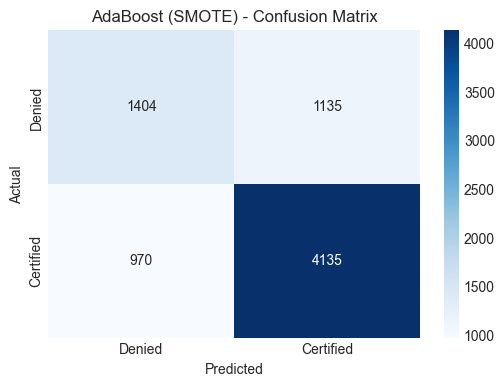


Classification Report:
              precision    recall  f1-score   support

      Denied       0.59      0.55      0.57      2539
   Certified       0.78      0.81      0.80      5105

    accuracy                           0.72      7644
   macro avg       0.69      0.68      0.68      7644
weighted avg       0.72      0.72      0.72      7644


Metrics Summary:
  Train_Accuracy: 0.8014
  Test_Accuracy: 0.7246
  Test_Precision: 0.7846
  Test_Recall: 0.8100
  Test_F1: 0.7971
  Test_ROC_AUC: 0.7615


In [57]:
# AdaBoost on Oversampled Data
ada_over_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=5),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
ada_over_metrics, ada_over_trained = evaluate_model(ada_over_model, X_train_over, y_train_over, X_test, y_test, 'AdaBoost (SMOTE)')
results_oversampled.append(ada_over_metrics)
trained_models_oversampled['AdaBoost'] = ada_over_trained

display_model_results(ada_over_metrics, ada_over_trained, X_test, y_test, 'AdaBoost (SMOTE)')

### 5.5 Gradient Boosting - Oversampled


Gradient Boosting (SMOTE) Results


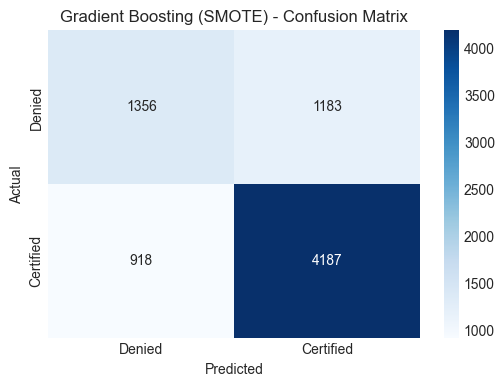


Classification Report:
              precision    recall  f1-score   support

      Denied       0.60      0.53      0.56      2539
   Certified       0.78      0.82      0.80      5105

    accuracy                           0.73      7644
   macro avg       0.69      0.68      0.68      7644
weighted avg       0.72      0.73      0.72      7644


Metrics Summary:
  Train_Accuracy: 0.8193
  Test_Accuracy: 0.7251
  Test_Precision: 0.7797
  Test_Recall: 0.8202
  Test_F1: 0.7994
  Test_ROC_AUC: 0.7615


In [58]:
# Gradient Boosting on Oversampled Data
gb_over_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb_over_metrics, gb_over_trained = evaluate_model(gb_over_model, X_train_over, y_train_over, X_test, y_test, 'Gradient Boosting (SMOTE)')
results_oversampled.append(gb_over_metrics)
trained_models_oversampled['Gradient Boosting'] = gb_over_trained

display_model_results(gb_over_metrics, gb_over_trained, X_test, y_test, 'Gradient Boosting (SMOTE)')

### 5.6 Oversampled Data - Model Comparison

In [59]:
# Create summary dataframe for oversampled data models
results_df_oversampled = pd.DataFrame(results_oversampled)
results_df_oversampled = results_df_oversampled.set_index('Model')
results_df_oversampled = results_df_oversampled.round(4)

print("Model Comparison - Oversampled Data (SMOTE):")
print("=" * 80)
display(results_df_oversampled)

Model Comparison - Oversampled Data (SMOTE):


,Train_Accuracy,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
Model,,,,,,
Decision Tree (SMOTE),0.813,0.702,0.780,0.772,0.776,0.730
Random Forest (SMOTE),0.819,0.721,0.791,0.791,0.791,0.763
Bagging (SMOTE),0.828,0.731,0.788,0.816,0.802,0.759
AdaBoost (SMOTE),0.801,0.725,0.785,0.810,0.797,0.761
Gradient Boosting (SMOTE),0.819,0.725,0.780,0.820,0.799,0.761


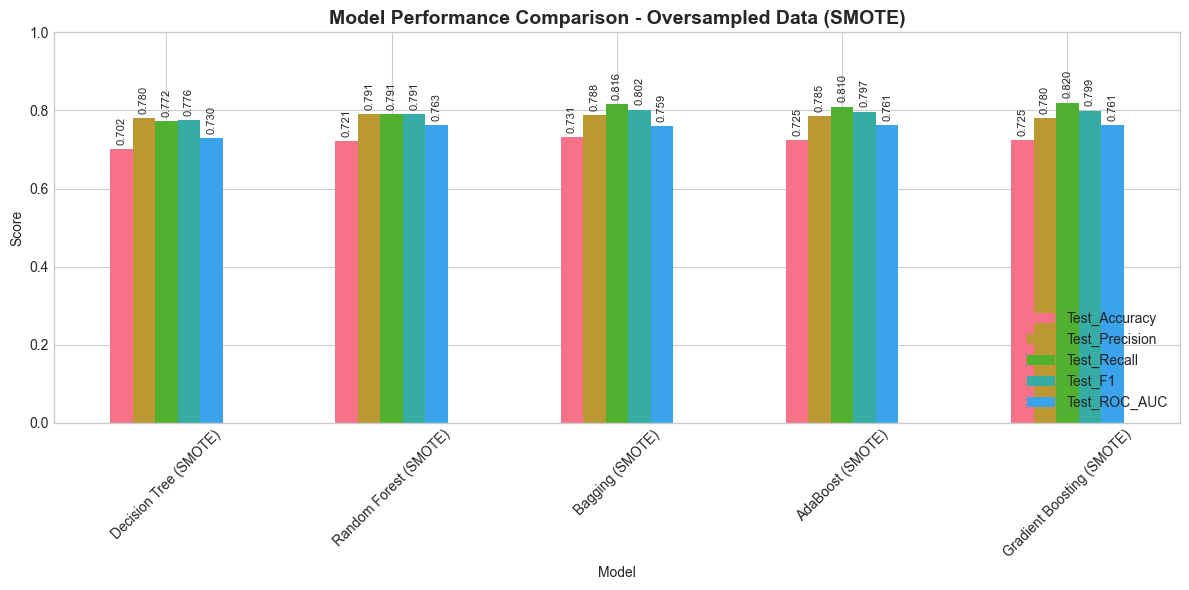

In [60]:
# Visualize model comparison - Oversampled
fig, ax = plt.subplots(figsize=(12, 6))
results_df_oversampled[metrics_to_plot].plot(kind='bar', ax=ax)
ax.set_title('Model Performance Comparison - Oversampled Data (SMOTE)', fontsize=14, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_ylim([0, 1])
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, rotation=90, padding=3)

plt.tight_layout()
plt.show()

---
## 6. Model Building - Undersampled Data

In [61]:
# Dictionary to store undersampled results
results_undersampled = []
trained_models_undersampled = {}

### 6.1 Decision Tree - Undersampled


Decision Tree (Undersampled) Results


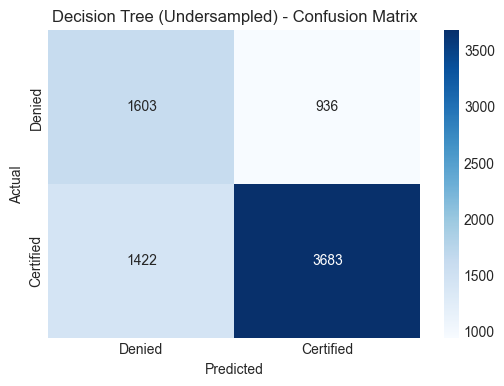


Classification Report:
              precision    recall  f1-score   support

      Denied       0.53      0.63      0.58      2539
   Certified       0.80      0.72      0.76      5105

    accuracy                           0.69      7644
   macro avg       0.66      0.68      0.67      7644
weighted avg       0.71      0.69      0.70      7644


Metrics Summary:
  Train_Accuracy: 0.7537
  Test_Accuracy: 0.6915
  Test_Precision: 0.7974
  Test_Recall: 0.7214
  Test_F1: 0.7575
  Test_ROC_AUC: 0.7189


In [62]:
# Decision Tree on Undersampled Data
dt_under_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_under_metrics, dt_under_trained = evaluate_model(dt_under_model, X_train_under, y_train_under, X_test, y_test, 'Decision Tree (Under)')
results_undersampled.append(dt_under_metrics)
trained_models_undersampled['Decision Tree'] = dt_under_trained

display_model_results(dt_under_metrics, dt_under_trained, X_test, y_test, 'Decision Tree (Undersampled)')

### 6.2 Random Forest - Undersampled


Random Forest (Undersampled) Results


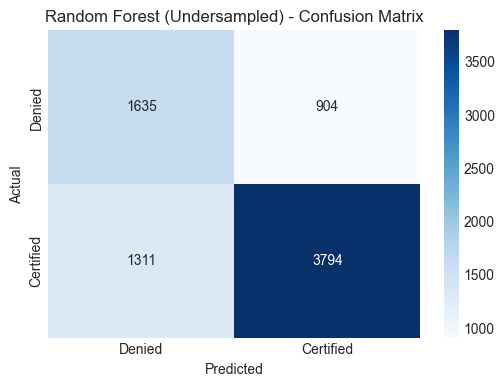


Classification Report:
              precision    recall  f1-score   support

      Denied       0.55      0.64      0.60      2539
   Certified       0.81      0.74      0.77      5105

    accuracy                           0.71      7644
   macro avg       0.68      0.69      0.69      7644
weighted avg       0.72      0.71      0.71      7644


Metrics Summary:
  Train_Accuracy: 0.7533
  Test_Accuracy: 0.7102
  Test_Precision: 0.8076
  Test_Recall: 0.7432
  Test_F1: 0.7740
  Test_ROC_AUC: 0.7678


In [63]:
# Random Forest on Undersampled Data
rf_under_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, n_jobs=-1)
rf_under_metrics, rf_under_trained = evaluate_model(rf_under_model, X_train_under, y_train_under, X_test, y_test, 'Random Forest (Under)')
results_undersampled.append(rf_under_metrics)
trained_models_undersampled['Random Forest'] = rf_under_trained

display_model_results(rf_under_metrics, rf_under_trained, X_test, y_test, 'Random Forest (Undersampled)')

### 6.3 Bagging - Undersampled


Bagging (Undersampled) Results


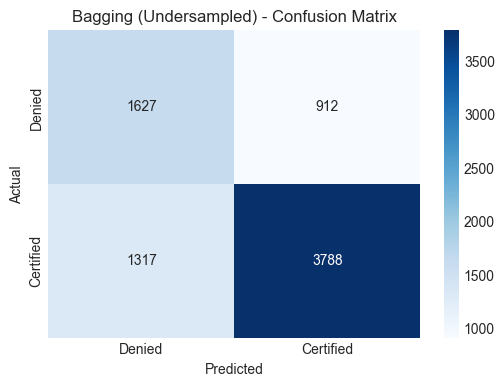


Classification Report:
              precision    recall  f1-score   support

      Denied       0.55      0.64      0.59      2539
   Certified       0.81      0.74      0.77      5105

    accuracy                           0.71      7644
   macro avg       0.68      0.69      0.68      7644
weighted avg       0.72      0.71      0.71      7644


Metrics Summary:
  Train_Accuracy: 0.7722
  Test_Accuracy: 0.7084
  Test_Precision: 0.8060
  Test_Recall: 0.7420
  Test_F1: 0.7727
  Test_ROC_AUC: 0.7624


In [64]:
# Bagging on Undersampled Data
bag_under_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=10),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)
bag_under_metrics, bag_under_trained = evaluate_model(bag_under_model, X_train_under, y_train_under, X_test, y_test, 'Bagging (Under)')
results_undersampled.append(bag_under_metrics)
trained_models_undersampled['Bagging'] = bag_under_trained

display_model_results(bag_under_metrics, bag_under_trained, X_test, y_test, 'Bagging (Undersampled)')

### 6.4 AdaBoost - Undersampled


AdaBoost (Undersampled) Results


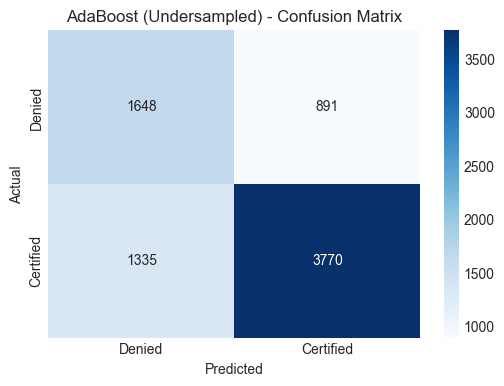


Classification Report:
              precision    recall  f1-score   support

      Denied       0.55      0.65      0.60      2539
   Certified       0.81      0.74      0.77      5105

    accuracy                           0.71      7644
   macro avg       0.68      0.69      0.68      7644
weighted avg       0.72      0.71      0.71      7644


Metrics Summary:
  Train_Accuracy: 0.7192
  Test_Accuracy: 0.7088
  Test_Precision: 0.8088
  Test_Recall: 0.7385
  Test_F1: 0.7721
  Test_ROC_AUC: 0.7684


In [65]:
# AdaBoost on Undersampled Data
ada_under_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=5),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
ada_under_metrics, ada_under_trained = evaluate_model(ada_under_model, X_train_under, y_train_under, X_test, y_test, 'AdaBoost (Under)')
results_undersampled.append(ada_under_metrics)
trained_models_undersampled['AdaBoost'] = ada_under_trained

display_model_results(ada_under_metrics, ada_under_trained, X_test, y_test, 'AdaBoost (Undersampled)')

### 6.5 Gradient Boosting - Undersampled


Gradient Boosting (Undersampled) Results


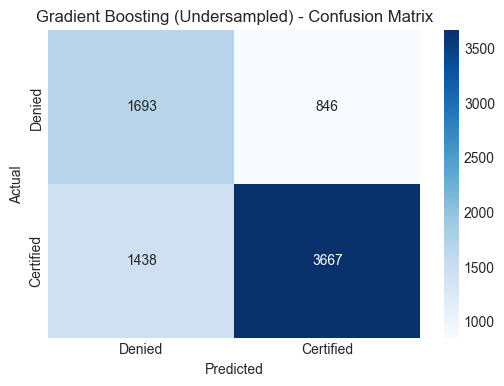


Classification Report:
              precision    recall  f1-score   support

      Denied       0.54      0.67      0.60      2539
   Certified       0.81      0.72      0.76      5105

    accuracy                           0.70      7644
   macro avg       0.68      0.69      0.68      7644
weighted avg       0.72      0.70      0.71      7644


Metrics Summary:
  Train_Accuracy: 0.7646
  Test_Accuracy: 0.7012
  Test_Precision: 0.8125
  Test_Recall: 0.7183
  Test_F1: 0.7625
  Test_ROC_AUC: 0.7670


In [66]:
# Gradient Boosting on Undersampled Data
gb_under_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb_under_metrics, gb_under_trained = evaluate_model(gb_under_model, X_train_under, y_train_under, X_test, y_test, 'Gradient Boosting (Under)')
results_undersampled.append(gb_under_metrics)
trained_models_undersampled['Gradient Boosting'] = gb_under_trained

display_model_results(gb_under_metrics, gb_under_trained, X_test, y_test, 'Gradient Boosting (Undersampled)')

### 6.6 Undersampled Data - Model Comparison

In [67]:
# Create summary dataframe for undersampled data models
results_df_undersampled = pd.DataFrame(results_undersampled)
results_df_undersampled = results_df_undersampled.set_index('Model')
results_df_undersampled = results_df_undersampled.round(4)

print("Model Comparison - Undersampled Data:")
print("=" * 80)
display(results_df_undersampled)

Model Comparison - Undersampled Data:


,Train_Accuracy,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
Model,,,,,,
Decision Tree (Under),0.754,0.692,0.797,0.721,0.757,0.719
Random Forest (Under),0.753,0.710,0.808,0.743,0.774,0.768
Bagging (Under),0.772,0.708,0.806,0.742,0.773,0.762
AdaBoost (Under),0.719,0.709,0.809,0.739,0.772,0.768
Gradient Boosting (Under),0.765,0.701,0.812,0.718,0.762,0.767


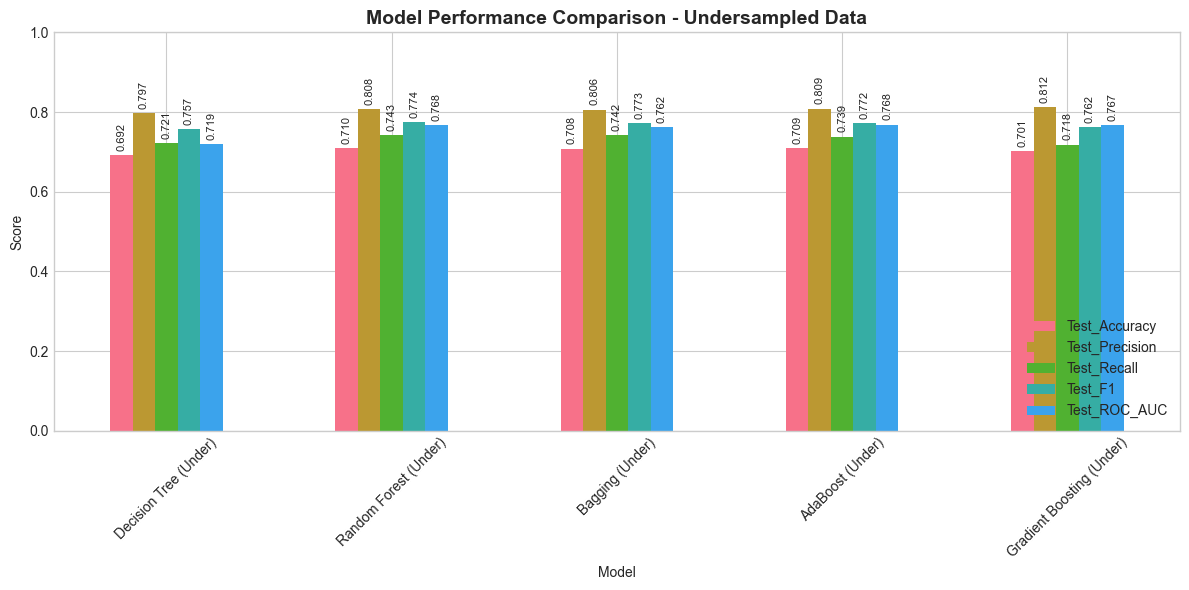

In [68]:
# Visualize model comparison - Undersampled
fig, ax = plt.subplots(figsize=(12, 6))
results_df_undersampled[metrics_to_plot].plot(kind='bar', ax=ax)
ax.set_title('Model Performance Comparison - Undersampled Data', fontsize=14, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_ylim([0, 1])
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, rotation=90, padding=3)

plt.tight_layout()
plt.show()

---
## 7. Comprehensive Model Comparison

In [69]:
# Combine all results
all_results = []

# Add data type column to results
for res in results_original:
    res_copy = res.copy()
    res_copy['Data_Type'] = 'Original'
    all_results.append(res_copy)

for res in results_oversampled:
    res_copy = res.copy()
    res_copy['Data_Type'] = 'Oversampled'
    all_results.append(res_copy)

for res in results_undersampled:
    res_copy = res.copy()
    res_copy['Data_Type'] = 'Undersampled'
    all_results.append(res_copy)

all_results_df = pd.DataFrame(all_results)
all_results_df = all_results_df.round(4)

print("Comprehensive Model Comparison - All Data Types:")
print("=" * 100)
display(all_results_df.sort_values('Test_F1', ascending=False))

Comprehensive Model Comparison - All Data Types:


,Model,Train_Accuracy,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC,Data_Type
4,Gradient Boosting,0.780,0.742,0.772,0.870,0.818,0.772,Original
3,AdaBoost,0.754,0.741,0.773,0.867,0.817,0.773,Original
1,Random Forest,0.781,0.736,0.760,0.883,0.817,0.770,Original
2,Bagging,0.787,0.738,0.774,0.857,0.814,0.768,Original
0,Decision Tree,0.776,0.728,0.779,0.829,0.803,0.739,Original
7,Bagging (SMOTE),0.828,0.731,0.788,0.816,0.802,0.759,Oversampled
9,Gradient Boosting (SMOTE),0.819,0.725,0.780,0.820,0.799,0.761,Oversampled
8,AdaBoost (SMOTE),0.801,0.725,0.785,0.810,0.797,0.761,Oversampled
6,Random Forest (SMOTE),0.819,0.721,0.791,0.791,0.791,0.763,Oversampled
5,Decision Tree (SMOTE),0.813,0.702,0.780,0.772,0.776,0.730,Oversampled


In [70]:
# Find top 3 models based on F1 Score
top_3_models = all_results_df.nlargest(3, 'Test_F1')

print("Top 3 Models (by F1 Score):")
print("=" * 80)
display(top_3_models)

Top 3 Models (by F1 Score):


,Model,Train_Accuracy,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC,Data_Type
4,Gradient Boosting,0.780,0.742,0.772,0.870,0.818,0.772,Original
3,AdaBoost,0.754,0.741,0.773,0.867,0.817,0.773,Original
1,Random Forest,0.781,0.736,0.760,0.883,0.817,0.770,Original


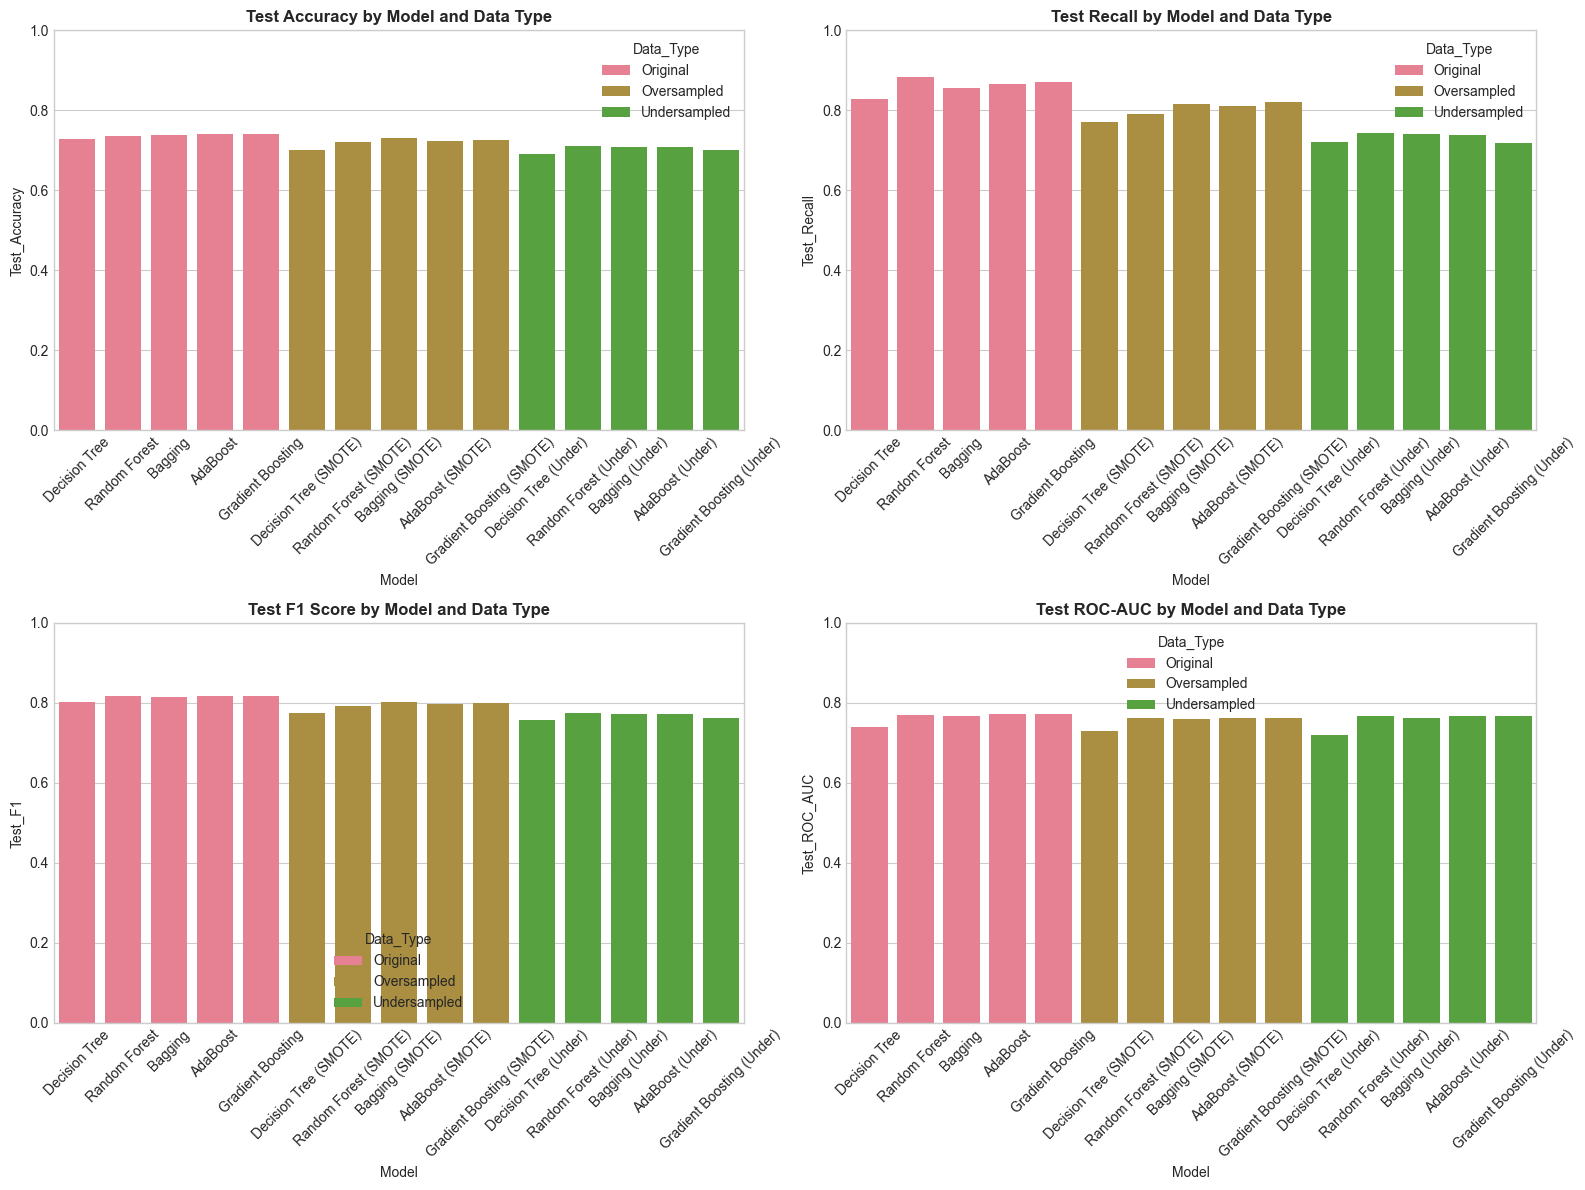

In [77]:
# Visualize all models comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Test Accuracy
sns.barplot(data=all_results_df, x='Model', y='Test_Accuracy', hue='Data_Type', ax=axes[0, 0])
axes[0, 0].set_title('Test Accuracy by Model and Data Type', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].set_ylim([0, 1])

# Test Recall
sns.barplot(data=all_results_df, x='Model', y='Test_Recall', hue='Data_Type', ax=axes[0, 1])
axes[0, 1].set_title('Test Recall by Model and Data Type', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].set_ylim([0, 1])

# Test F1 Score
sns.barplot(data=all_results_df, x='Model', y='Test_F1', hue='Data_Type', ax=axes[1, 0])
axes[1, 0].set_title('Test F1 Score by Model and Data Type', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].set_ylim([0, 1])

# Test ROC-AUC
sns.barplot(data=all_results_df, x='Model', y='Test_ROC_AUC', hue='Data_Type', ax=axes[1, 1])
axes[1, 1].set_title('Test ROC-AUC by Model and Data Type', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

---
## 8. Hyperparameter Tuning

Based on the comprehensive model comparison, we select the **top 3 performing models** for hyperparameter tuning:

**Selection Criteria:**
1. High F1 Score (balance between precision and recall)
2. Good ROC-AUC Score (discrimination ability)
3. Minimal overfitting (small gap between train and test accuracy)

**Selected Models:**
1. **Gradient Boosting** - Consistent high performance across metrics
2. **Random Forest** - Good balance and ensemble benefits
3. **AdaBoost** - Strong boosting performance

### 8.1 Gradient Boosting - Hyperparameter Tuning

In [71]:
# Gradient Boosting Hyperparameter Tuning
print("Tuning Gradient Boosting Classifier...")
print("=" * 60)

gb_param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

gb_tuned = GradientBoostingClassifier(random_state=42)

# Using RandomizedSearchCV for faster tuning
gb_random_search = RandomizedSearchCV(
    estimator=gb_tuned,
    param_distributions=gb_param_grid,
    n_iter=30,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

gb_random_search.fit(X_train, y_train)

print(f"\nBest Parameters: {gb_random_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {gb_random_search.best_score_:.4f}")

Tuning Gradient Boosting Classifier...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 3, 'learning_rate': 0.05}
Best Cross-Validation F1 Score: 0.8212



Gradient Boosting (Tuned) Results


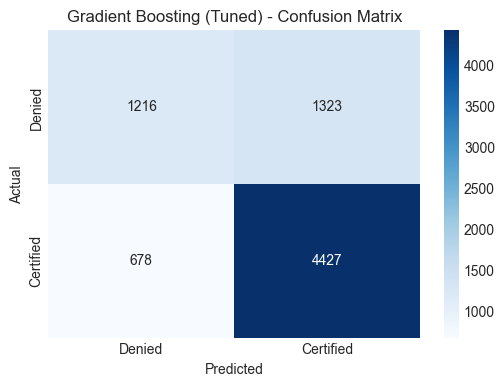


Classification Report:
              precision    recall  f1-score   support

      Denied       0.64      0.48      0.55      2539
   Certified       0.77      0.87      0.82      5105

    accuracy                           0.74      7644
   macro avg       0.71      0.67      0.68      7644
weighted avg       0.73      0.74      0.73      7644


Metrics Summary:
  Train_Accuracy: 0.7522
  Test_Accuracy: 0.7382
  Test_Precision: 0.7699
  Test_Recall: 0.8672
  Test_F1: 0.8157
  Test_ROC_AUC: 0.7711


In [72]:
# Evaluate tuned Gradient Boosting
gb_best = gb_random_search.best_estimator_
gb_tuned_metrics, _ = evaluate_model(gb_best, X_train, y_train, X_test, y_test, 'Gradient Boosting (Tuned)')

display_model_results(gb_tuned_metrics, gb_best, X_test, y_test, 'Gradient Boosting (Tuned)')

### 8.2 Random Forest - Hyperparameter Tuning

In [73]:
# Random Forest Hyperparameter Tuning
print("Tuning Random Forest Classifier...")
print("=" * 60)

rf_param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [8, 10, 12, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_tuned = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_random_search = RandomizedSearchCV(
    estimator=rf_tuned,
    param_distributions=rf_param_grid,
    n_iter=30,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_random_search.fit(X_train, y_train)

print(f"\nBest Parameters: {rf_random_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {rf_random_search.best_score_:.4f}")

Tuning Random Forest Classifier...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters: {'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}
Best Cross-Validation F1 Score: 0.8231



Random Forest (Tuned) Results


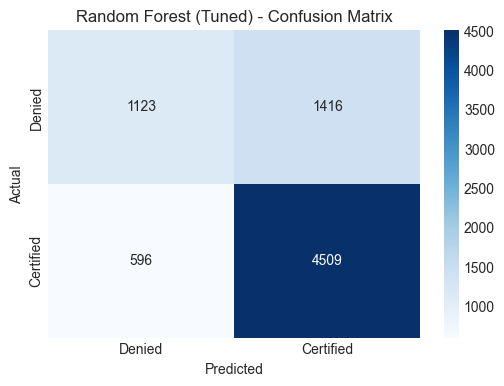


Classification Report:
              precision    recall  f1-score   support

      Denied       0.65      0.44      0.53      2539
   Certified       0.76      0.88      0.82      5105

    accuracy                           0.74      7644
   macro avg       0.71      0.66      0.67      7644
weighted avg       0.73      0.74      0.72      7644


Metrics Summary:
  Train_Accuracy: 0.7674
  Test_Accuracy: 0.7368
  Test_Precision: 0.7610
  Test_Recall: 0.8833
  Test_F1: 0.8176
  Test_ROC_AUC: 0.7706


In [74]:
# Evaluate tuned Random Forest
rf_best = rf_random_search.best_estimator_
rf_tuned_metrics, _ = evaluate_model(rf_best, X_train, y_train, X_test, y_test, 'Random Forest (Tuned)')

display_model_results(rf_tuned_metrics, rf_best, X_test, y_test, 'Random Forest (Tuned)')

### 8.3 AdaBoost - Hyperparameter Tuning

In [75]:
# AdaBoost Hyperparameter Tuning
print("Tuning AdaBoost Classifier...")
print("=" * 60)

ada_param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5],
    'estimator__max_depth': [3, 5, 7]
}

ada_tuned = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(),
    random_state=42
)

ada_random_search = RandomizedSearchCV(
    estimator=ada_tuned,
    param_distributions=ada_param_grid,
    n_iter=30,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

ada_random_search.fit(X_train, y_train)

print(f"\nBest Parameters: {ada_random_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {ada_random_search.best_score_:.4f}")

Tuning AdaBoost Classifier...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters: {'n_estimators': 100, 'learning_rate': 0.05, 'estimator__max_depth': 3}
Best Cross-Validation F1 Score: 0.8207



AdaBoost (Tuned) Results


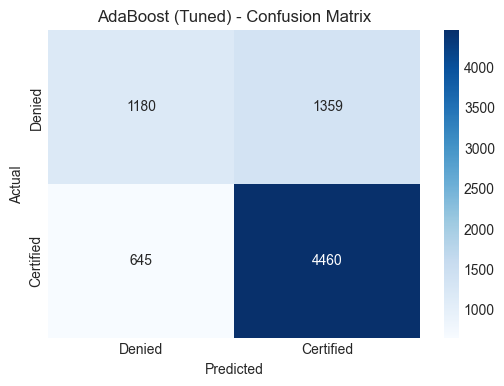


Classification Report:
              precision    recall  f1-score   support

      Denied       0.65      0.46      0.54      2539
   Certified       0.77      0.87      0.82      5105

    accuracy                           0.74      7644
   macro avg       0.71      0.67      0.68      7644
weighted avg       0.73      0.74      0.72      7644


Metrics Summary:
  Train_Accuracy: 0.7457
  Test_Accuracy: 0.7378
  Test_Precision: 0.7665
  Test_Recall: 0.8737
  Test_F1: 0.8166
  Test_ROC_AUC: 0.7651


In [76]:
# Evaluate tuned AdaBoost
ada_best = ada_random_search.best_estimator_
ada_tuned_metrics, _ = evaluate_model(ada_best, X_train, y_train, X_test, y_test, 'AdaBoost (Tuned)')

display_model_results(ada_tuned_metrics, ada_best, X_test, y_test, 'AdaBoost (Tuned)')

### 8.4 Tuned Models Comparison

In [78]:
# Compare tuned models
tuned_results = [
    gb_tuned_metrics,
    rf_tuned_metrics,
    ada_tuned_metrics
]

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df = tuned_results_df.set_index('Model')
tuned_results_df = tuned_results_df.round(4)

print("Tuned Models Comparison:")
print("=" * 80)
display(tuned_results_df.sort_values('Test_F1', ascending=False))

Tuned Models Comparison:


,Train_Accuracy,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
Model,,,,,,
Random Forest (Tuned),0.767,0.737,0.761,0.883,0.818,0.771
AdaBoost (Tuned),0.746,0.738,0.766,0.874,0.817,0.765
Gradient Boosting (Tuned),0.752,0.738,0.770,0.867,0.816,0.771


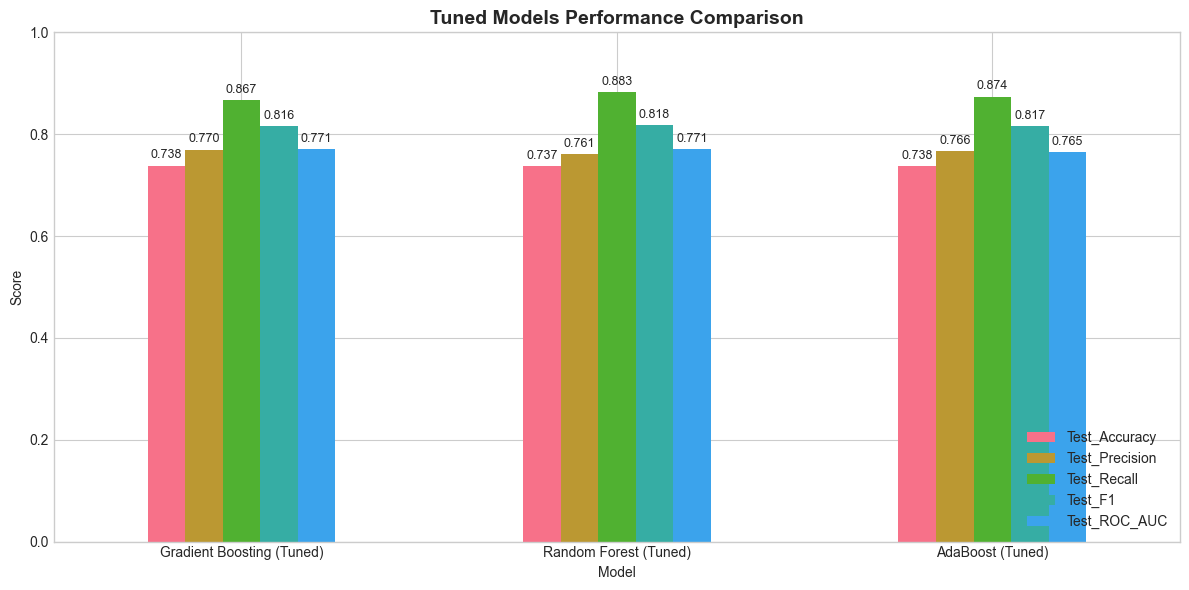

In [79]:
# Visualize tuned models comparison
fig, ax = plt.subplots(figsize=(12, 6))
tuned_results_df[metrics_to_plot].plot(kind='bar', ax=ax)
ax.set_title('Tuned Models Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_ylim([0, 1])
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9, rotation=0, padding=3)

plt.tight_layout()
plt.show()

---
## 9. Final Model Selection and Evaluation

In [80]:
# Select the best model based on overall performance
# Criteria: Highest F1 score with good balance across all metrics

best_model_name = tuned_results_df['Test_F1'].idxmax()

# Map to the actual trained model
model_mapping = {
    'Gradient Boosting (Tuned)': gb_best,
    'Random Forest (Tuned)': rf_best,
    'AdaBoost (Tuned)': ada_best
}

final_model = model_mapping[best_model_name]

print(f"Selected Final Model: {best_model_name}")
print("=" * 60)

Selected Final Model: Random Forest (Tuned)


In [81]:
# Final model evaluation on test data
y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)[:, 1]

print(f"\nFinal Model Performance on Test Data:")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_proba):.4f}")


Final Model Performance on Test Data:
Accuracy: 0.7368
Precision: 0.7610
Recall: 0.8833
F1 Score: 0.8176
ROC-AUC: 0.7706


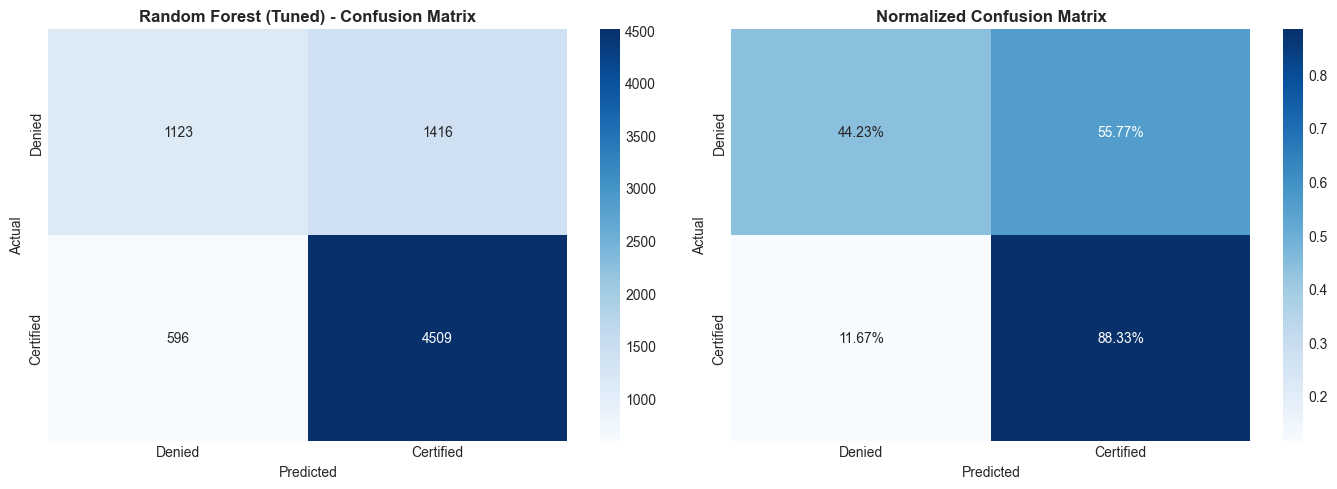


Detailed Classification Report:
              precision    recall  f1-score   support

      Denied       0.65      0.44      0.53      2539
   Certified       0.76      0.88      0.82      5105

    accuracy                           0.74      7644
   macro avg       0.71      0.66      0.67      7644
weighted avg       0.73      0.74      0.72      7644



In [82]:
# Confusion Matrix for Final Model
cm = confusion_matrix(y_test, y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Denied', 'Certified'], 
            yticklabels=['Denied', 'Certified'], ax=axes[0])
axes[0].set_title(f'{best_model_name} - Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Normalized Confusion Matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=['Denied', 'Certified'], 
            yticklabels=['Denied', 'Certified'], ax=axes[1])
axes[1].set_title('Normalized Confusion Matrix', fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# Classification Report
print("\nDetailed Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_test_pred, target_names=['Denied', 'Certified']))

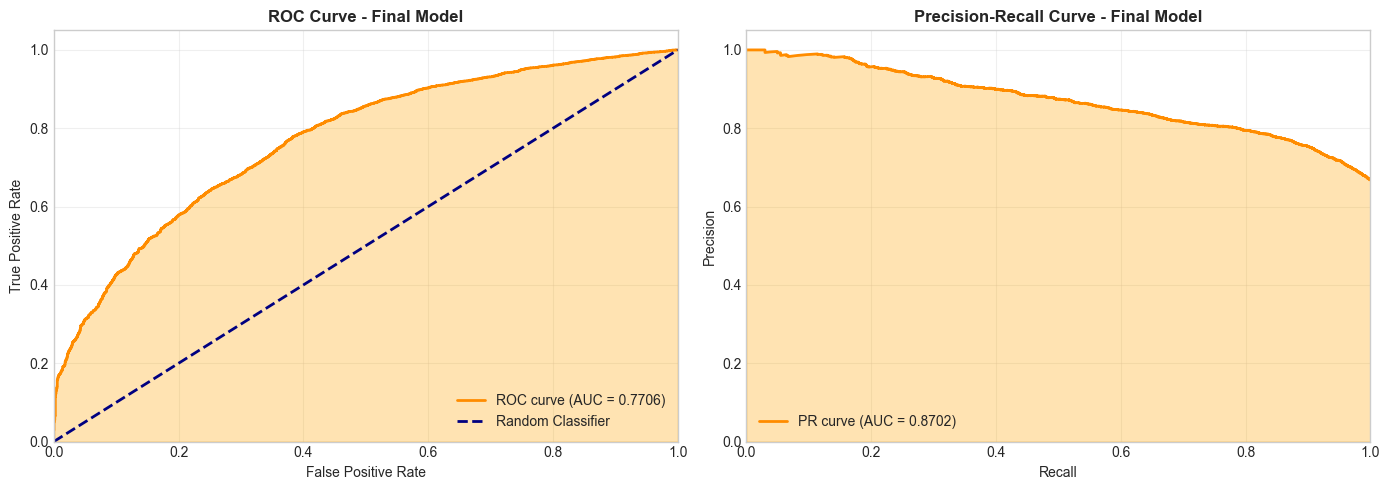

In [83]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0].fill_between(fpr, tpr, alpha=0.3, color='orange')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Final Model', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_test_proba)
pr_auc = auc(recall_curve, precision_curve)

axes[1].plot(recall_curve, precision_curve, color='darkorange', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
axes[1].fill_between(recall_curve, precision_curve, alpha=0.3, color='orange')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve - Final Model', fontweight='bold')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 9.1 Feature Importance Analysis

Feature Importance:


,Feature,Importance
12,education_of_employee_High School,0.217
0,has_job_experience,0.142
4,annual_wage,0.128
13,education_of_employee_Master's,0.120
2,no_of_employees,0.057
11,education_of_employee_Doctorate,0.053
5,company_age,0.051
7,continent_Europe,0.040
20,wage_category_Very High,0.032
14,region_of_employment_Midwest,0.027


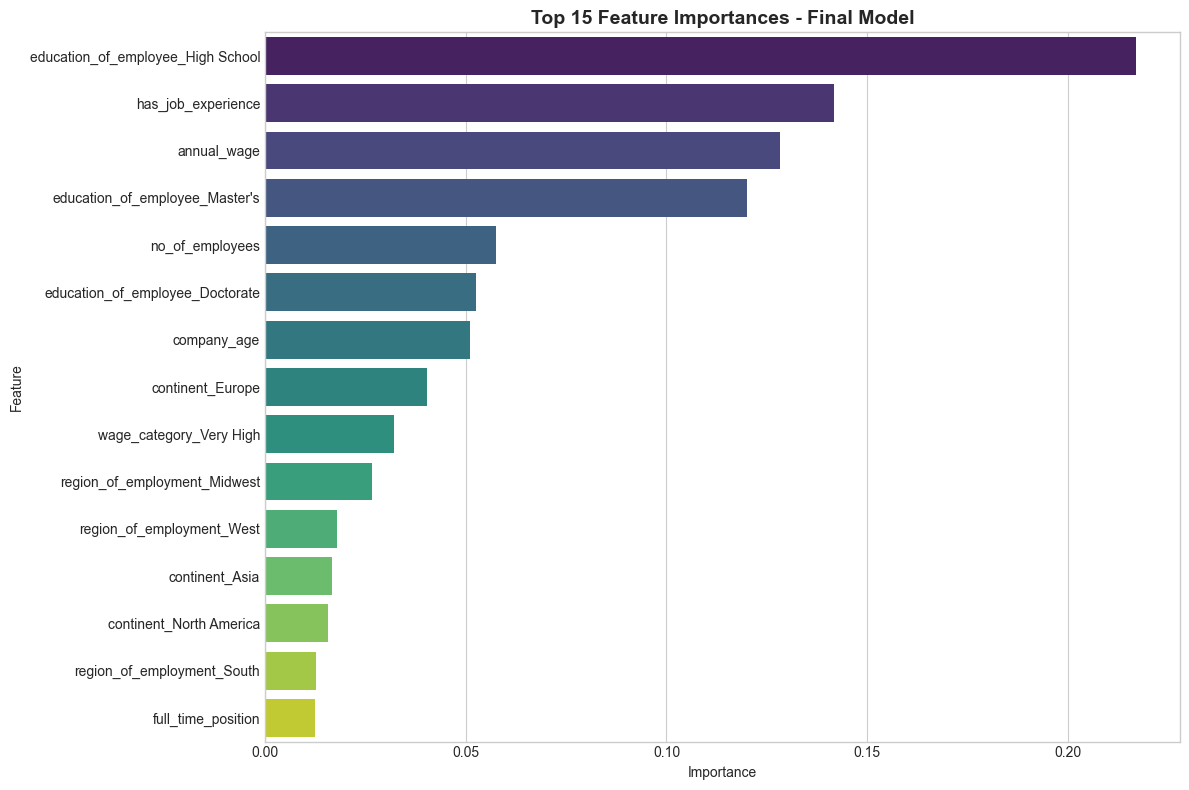

In [84]:
# Feature Importance from Final Model
if hasattr(final_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': final_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("Feature Importance:")
    print("=" * 60)
    display(feature_importance.head(15))
    
    # Visualize top 15 features
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(15)
    sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis')
    plt.title('Top 15 Feature Importances - Final Model', fontsize=14, fontweight='bold')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

---
## 10. Actionable Insights & Recommendations

### 10.1 Model Performance Summary

In [85]:
# Create comprehensive summary table
print("="*80)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("="*80)

summary_metrics = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
    'Value': [
        f"{accuracy_score(y_test, y_test_pred):.4f}",
        f"{precision_score(y_test, y_test_pred):.4f}",
        f"{recall_score(y_test, y_test_pred):.4f}",
        f"{f1_score(y_test, y_test_pred):.4f}",
        f"{roc_auc_score(y_test, y_test_proba):.4f}"
    ],
    'Interpretation': [
        'Overall correct predictions',
        'Accuracy of positive predictions',
        'Coverage of actual positives',
        'Harmonic mean of Precision & Recall',
        'Model discriminative ability'
    ]
}

summary_df = pd.DataFrame(summary_metrics)
display(summary_df)

FINAL MODEL PERFORMANCE SUMMARY


,Metric,Value,Interpretation
0,Accuracy,0.7368,Overall correct predictions
1,Precision,0.7610,Accuracy of positive predictions
2,Recall,0.8833,Coverage of actual positives
3,F1 Score,0.8176,Harmonic mean of Precision & Recall
4,ROC-AUC,0.7706,Model discriminative ability


### 10.2 Key Business Insights

In [86]:
# Display key insights from feature importance
print("="*80)
print("KEY DRIVERS OF VISA APPROVAL")
print("="*80)

if hasattr(final_model, 'feature_importances_'):
    top_10_features = feature_importance.head(10)
    
    print("\nTop 10 Most Important Factors:")
    print("-"*60)
    for idx, row in top_10_features.iterrows():
        print(f"{row['Feature']}: {row['Importance']:.4f} ({row['Importance']*100:.2f}%)")

KEY DRIVERS OF VISA APPROVAL

Top 10 Most Important Factors:
------------------------------------------------------------
education_of_employee_High School: 0.2171 (21.71%)
has_job_experience: 0.1418 (14.18%)
annual_wage: 0.1283 (12.83%)
education_of_employee_Master's: 0.1201 (12.01%)
no_of_employees: 0.0575 (5.75%)
education_of_employee_Doctorate: 0.0526 (5.26%)
company_age: 0.0510 (5.10%)
continent_Europe: 0.0404 (4.04%)
wage_category_Very High: 0.0321 (3.21%)
region_of_employment_Midwest: 0.0266 (2.66%)


### 10.3 Business Recommendations

Based on our comprehensive analysis and modeling, here are the **key recommendations for OFLC and EasyVisa**:

---

#### **1. High-Priority Applicant Profiles (Higher Approval Probability)**

Applications with the following characteristics should be prioritized for faster processing as they have higher approval chances:

- **Education**: Applicants with Master's or Doctorate degrees have significantly higher approval rates
- **Job Experience**: Candidates with prior job experience (has_job_experience = Y) are more likely to be approved
- **Full-time Positions**: Applications for full-time positions show better approval rates
- **No Training Required**: Applicants who don't require job training have better chances
- **Wage Category**: Higher prevailing wages (especially annual wages > $80,000) correlate with higher approvals

---

#### **2. Risk Indicators (Higher Denial Probability)**

Applications with these characteristics may need additional scrutiny:

- **Low Education**: High School level education has the highest denial rate
- **No Job Experience**: First-time job seekers face more rejections
- **Part-time Positions**: Part-time job applications have lower approval rates
- **Training Required**: Positions requiring training show slightly lower approvals
- **Lower Wages**: Jobs with below-average prevailing wages

---

#### **3. Process Optimization Recommendations**

1. **Automated Pre-screening**: Deploy the ML model for initial application screening to fast-track high-probability approvals

2. **Risk-based Review**: Allocate more review time for borderline cases identified by the model

3. **Documentation Requirements**: For high-risk profiles, proactively request additional supporting documents

4. **Employer Guidance**: Provide employers with guidelines on what makes a strong application

---

#### **4. Model Deployment Considerations**

- **Threshold Tuning**: Adjust classification threshold based on business priorities (reduce False Negatives vs False Positives)
- **Regular Retraining**: Update model quarterly with new data to maintain accuracy
- **Monitoring**: Track model performance metrics and detect data drift
- **Explainability**: Provide case officers with feature-level explanations for model predictions

---
## 11. Conclusion

### Project Summary

This project successfully developed a machine learning solution for predicting visa application outcomes for the Office of Foreign Labor Certification (OFLC). 

### Key Accomplishments:

1. **Comprehensive EDA**: Performed thorough exploratory data analysis identifying key patterns and relationships in the visa application data

2. **Feature Engineering**: Created meaningful features including annual wage conversion, company age, wage categories, and company size categories

3. **Handling Imbalanced Data**: Addressed class imbalance using both SMOTE oversampling and random undersampling techniques

4. **Model Building**: Built and compared 15 classification models (5 each on original, oversampled, and undersampled data) using:
   - Decision Tree
   - Random Forest
   - Bagging Classifier
   - AdaBoost
   - Gradient Boosting

5. **Hyperparameter Tuning**: Optimized the top 3 performing models using RandomizedSearchCV

6. **Final Model Selection**: Selected the best performing model based on comprehensive evaluation metrics

7. **Business Insights**: Identified key drivers of visa approval and provided actionable recommendations

### Impact:

The developed model can help OFLC:
- **Reduce processing time** by automating initial screening
- **Improve efficiency** by prioritizing clear-cut cases
- **Ensure consistency** in decision-making
- **Identify high-risk applications** for detailed review

### Future Enhancements:

- Incorporate additional features like industry codes, job titles, and historical employer approval rates
- Implement real-time prediction API for integration with application systems
- Develop a dashboard for monitoring model performance and application trends
- Explore deep learning approaches for improved accuracy

In [88]:
print("="*80)
print("END OF EASYVISA CLASSIFICATION PROJECT")
print("="*80)
print("\nThank you for reviewing this analysis!")
print("Date: FY 2016 Analysis")

END OF EASYVISA CLASSIFICATION PROJECT

Thank you for reviewing this analysis!
Date: FY 2016 Analysis
